# Построение модели поведенческого скоринга для прогнозирования просрочек на 90 дней

---

**Описание исследования**

Необходимо разработать модель поведенческого скоринга для действующего портфеля потребительских кредитов. В отличие от предкредитного скоринга, данная модель должна оценивать риск возникновения дефолта (просрочки более 90 дней) на основе актуального поведения клиента. Это позволит банку заблаговременно идентифицировать проблемных заёмщиков, оптимизировать объем резервов (ожидаемый прирост ликвидности 5–10%) и снизить регуляторные риски со стороны ЦБ. Задача классификации - предсказать вероятность дефолта на горизонте 12 месяцев.

---

**Цель исследования**

Разработать и обучить модель бинарной классификации для прогнозирования возникновения просрочки платежа длительностью 90+ дней в течение следующих 12 месяцев.

- Тип задачи: Бинарная классификация.

- Целевая переменная: Факт возникновения дефолта (1 - просрочка ≥90 дней в горизонте 12 месяцев, 0 - отсутствие такой просрочки).

- Особенности таргета: Используется метод скользящего окна с горизонтом H=12 месяцев.

- Ключевой вызов: Поиск оптимального порога классификации для баланса между объемом бизнеса и уровнем риска.

- Бизнес-метрики: 
    
    - Approval Rate: Доля клиентов, признанных моделью надежными.

    - Default Rate: Доля реальных дефолтов среди одобренных клиентов.

    - Missed Defaults Rate (1−Recall): Доля пропущенных дефолтов от общего числа плохих заемщиков.

---

**Задачи исследования**

- Анализ и подготовка данных: Изучение временной оси, обработка пропусков и корректное формирование целевой переменной по методу скользящего окна.

- EDA: Исследование признаков, описывающих финансовое поведение клиентов, и поиск ранних сигналов ухудшения платежной дисциплины.

- Построение моделей: Обучение ансамблей или градиентного бустинга для детекции скрытых паттернов дефолта.

- Оптимизация порога: Настройка порога вероятности для достижения целевых показателей по Approval Rate, Default Rate и Missed Defaults Rate.

- Валидация: Проверка устойчивости модели на тестовом временном отрезке и интерпретация наиболее значимых факторов риска для бизнеса.

---

**Описание данных**

Для построения модели поведенческого скоринга используется массив из 8 таблиц. Данные включают как статичную информацию на момент выдачи кредита, так и динамические показатели, меняющиеся во времени.

1. Основа для формирования выборки и таргета

    В этих таблицах заложена логика обучения: кого предсказываем и что именно.

    - Таблица 1 (ds_15_loan_payment_credit.csv): История просрочек. Содержит ID, дату начала и длительность просрочки в днях. Используется для разметки целевой переменной (был ли факт просрочки ≥90 дней в течение года после score_date).

    - Таблица 8 (ds_15_cohort_grid.csv): Реестр дат проведения скоринга. Содержит пары ID клиента и score_date. Это «точки отсчета», для которых нужно собрать признаки и предсказать риск на 12 месяцев вперед.

2. Динамические характеристики (Поведение)

    Данные, которые обновляются ежемесячно и отражают текущее состояние дел клиента.

    - Таблица 2 (ds_15_transactions.csv): Транзакционная активность. Помесячные траты по категориям:

        - MCC_5411, 5300, 5722: Продукты, маркетплейсы, техника.

        - MCC_5814, 5812, 3990: Фастфуд, рестораны, сервисы Яндекса.

        - MCC_4900: Коммунальные платежи (ЖКУ).

    - Таблица 6 (ds_15_credit_rating.csv): Внешний кредитный рейтинг клиента на конкретные даты. Позволяет отследить, как менялась оценка надежности заемщика со стороны.

3. Социально-демографический и кредитный профиль

    Статичные или редко меняющиеся данные о заемщике.

    - Таблица 3 (ds_15_client_description.csv): Личные данные клиента (возраст, семейное положение, наличие иждивенцев) и дата, когда клиент начал пользоваться услугами банка.

    - Таблица 4 (ds_15_credit_description.csv): Финансовые условия на старте: заявленный доход и общая сумма кредита.

    - Таблица 5 (ds_15_mortgage_presence.csv): Сведения об ипотеке (наличие флага и дата открытия). Ипотека - это долгосрочный якорь, сильно влияющий на платежную дисциплину.

4. Внешние факторы

    - Таблица 7 (ds_15_macro_data.csv): Макроэкономические показатели (инфляция, безработица, ключевая ставка). Помогают модели понять, вызваны ли просрочки личными проблемами клиента или общим кризисом в стране.

---

## Перевод бизнес-задачи на язык машинного обучения

Методы и модели

- Модели: В качестве Baseline используем логистическую регрессию. Основной стек: деревья решений и бэггинг (RandomForest).

- Работа с данными: Агрегация транзакций по месяцам, создание временных лагов для кредитного рейтинга и макропоказателей.

- Threshold Tuning: Ключевой этап решения - подбор порога классификации для баланса метрик.

План решения

- Формирование витрины: Сборка всех 8 таблиц в единый датасет на основе сетки дат скоринга.

- Разметка: Расчет таргета методом скользящего окна.

- Обучение и валидация: Кросс-валидация и подбор гиперпараметров (Optuna).

- Бизнес-оптимизация: Выбор порога отсечения, удовлетворяющего требованиям банка по уровню риска.


## Загрузка необходимых библиотек

In [1]:
from pathlib import Path

In [3]:
req_path = Path("../../requirements.txt")
if req_path.exists():
    %pip install -qr {req_path}
else:
    %pip install -qU --force-reinstall "numpy<2.2.0" "pillow<12.0" pandas==2.2.2 numba scipy scikit-learn imbalanced-learn matplotlib seaborn phik joblib category_encoders optuna mlxtend

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 71.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 66.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 79.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 83.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 18.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 103.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 16.9 MB/s eta

In [ ]:
import joblib
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import optuna

from mlxtend.evaluate.time_series import GroupTimeSeriesSplit

import sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids

from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)

In [3]:
RANDOM_STATE = 42

## Загрузка данных

In [4]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive монтирован")
except ImportError:
    print("Локальное использование")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive монтирован


In [5]:
def get_df(file_name):
    local_path = Path(f'/content/drive/MyDrive/datasets/{file_name}')
    yp_path = Path(f'/datasets/{file_name}')

    if local_path.exists():
        df = pd.read_csv(local_path, sep=',', decimal='.')
    elif yp_path.exists():
        df = pd.read_csv(yp_path, sep=',', decimal='.')
    else:
        raise "Путь до датасета неверный"

    int_cols = df.select_dtypes(include=['integer']).columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    float_cols = df.select_dtypes(include=['float']).columns
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')

    print('-' * 70)
    print(file_name)
    display(df.head())
    df.info()

    return df

loan_payment_credit = get_df('ds_15_loan_payment_credit.csv')
transactions = get_df('ds_15_transactions.csv')
client_description = get_df('ds_15_client_description.csv')
credit_description = get_df('ds_15_credit_description.csv')
mortgage_presence = get_df('ds_15_mortgage_presence.csv')
credit_rating = get_df('ds_15_credit_rating.csv')
macro_data = get_df('ds_15_macro_data.csv')
cohort_grid = get_df('ds_15_cohort_grid.csv')

----------------------------------------------------------------------
ds_15_loan_payment_credit.csv


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int16 
dtypes: int16(1), object(2)
memory usage: 96.8+ KB
----------------------------------------------------------------------
ds_15_transactions.csv


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.760010,2156.67,1519.46,4352.90


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  object 
 1   date        577494 non-null  object 
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float32
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float32(1), float64(7), object(2)
memory usage: 41.9+ MB
----------------------------------------------------------------------
ds_15_client_description.csv


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   ID                 577494 non-null  object
 1   date               577494 non-null  object
 2   кредитный_рейтинг  577494 non-null  int16 
dtypes: int16(1), object(2)
memory usage: 9.9+ MB
----------------------------------------------------------------------
ds_15_macro_data.csv


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     object 
 1   учетная_ставка       84 non-null     float32
 2   уровень_безработицы  84 non-null     float32
 3   инфляция             84 non-null     float32
dtypes: float32(3), object(1)
memory usage: 1.8+ KB
----------------------------------------------------------------------
ds_15_cohort_grid.csv


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB


Предоставленный массив данных содержит 8 таблиц, охватывающих 13 500 клиентов и более 577 тысяч ежемесячных записей об их активности. Структура данных позволяет объединить статичные профили заемщиков (возраст, доход, семейное положение) с динамическими факторами: транзакциями по 8 категориям MCC-кодов, изменениями кредитного рейтинга и макроэкономическим контекстом. Объем целевых событий (5 500 записей о просрочках) достаточен для обучения моделей, а наличие ипотечных данных у половины базы и временной сетки скоринга дает возможность построить качественную поведенческую модель с использованием временных лагов.

## Исследовательский анализ данных

In [6]:
def show_features(df: pd.DataFrame):
    table = []
    
    num_cols, cat_cols = [], []
    for col in df.columns:
        nunique = df[col].nunique()
        if nunique > 10:
            num_cols.append(col)
        else:
            cat_cols.append(col)
        
        table.append({
            'Признак': col,
            'Уникальные значения': df[col].unique(),
            'Кол-во': nunique,
        })

    display(pd.DataFrame(table).sort_values('Кол-во', ascending=False))
    
    return num_cols, cat_cols

In [7]:
def create_num_plot(data, col):
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    
    hist = axes[0]
    data.plot(
        kind='hist',
        bins=70,
        grid=True,
        ax=hist
    )
    hist.set_title(f'Распределение: {col}', fontsize=12)
    hist.set_xlabel('Значение')
    hist.set_ylabel('Количество (log)')
    hist.set_yscale('log')
    
    box = axes[1]
    sns.boxplot(
        data=data,
        ax=box
    )
    box.set_title(f'Размах: {col}', fontsize=12)
    box.set_ylabel('Значение')
    box.grid(True)
    box.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    plt.close()

def show_num_plots(df, cols):
    for col in cols:
        create_num_plot(df[col], col)

In [8]:
def create_cat_plot(df, col):
    plt.figure(figsize=(12, 4)) 
    
    ax = sns.countplot(
        x=col,
        data=df,
        hue=col, 
        legend=False,
        palette='viridis', 
        dodge=False,
    )
    
    plt.title(f'Распределение: {col}', fontsize=12)
    plt.xlabel('Значение')
    plt.ylabel('Количество')

    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=1)

    plt.tight_layout()
    plt.show()
    plt.close()
    
def show_cat_plots(df, cols):
    for col in cols:
        create_cat_plot(df, col)

In [9]:
def show_missing_stats(df):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isna().sum(),
        'Доля пропусков': df.isna().mean() * 100
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return missing_stats \
            .sort_values(by='Кол-во пропусков', ascending=False) \
            .style.format({'Доля пропусков': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm')

In [10]:
def primary_analysis(df: pd.DataFrame, name):
    display(Markdown(f'### Анализ датафрейма: **{name}**'))
    
    display(Markdown(f'#### пропуски'))
    display(show_missing_stats(df))
    
    display(Markdown(f'#### дубликаты'))
    print("Явные дубликаты строк:", df.duplicated().sum())

    display(Markdown(f'#### числовые признаки'))
    num_df = df.select_dtypes(include=['number'])
    if not num_df.empty:
        display(num_df.describe())
        num_cols, cat_cols = show_features(num_df)
        
        if len(num_cols) > 0:
            show_num_plots(num_df, num_cols)

        if len(cat_cols) > 0:
            show_cat_plots(num_df, cat_cols)
    else:
        print('Отсутствуют')
            

    print()

    display(Markdown(f'#### категориальные признаки'))
    cat_df = df.select_dtypes(include=['object'])
    if not cat_df.empty:
        display(cat_df.describe())
        _, cat_cols = show_features(cat_df)

        if len(cat_cols) > 0:
            show_cat_plots(cat_df, cat_cols)
    else:
        print('Отсутствуют')
        
    print('-' * 70)

### Анализ датафрейма: **кредитный платеж**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,просрочка_дней
count,5500.000000
mean,114.748000
std,20.362422
min,80.000000
25%,97.000000
50%,115.000000
75%,132.000000
max,150.000000


,Признак,Уникальные значения,Кол-во
0,просрочка_дней,"[120, 121, 87, 109, 84, 83, 101, 112, 105, 146...",71


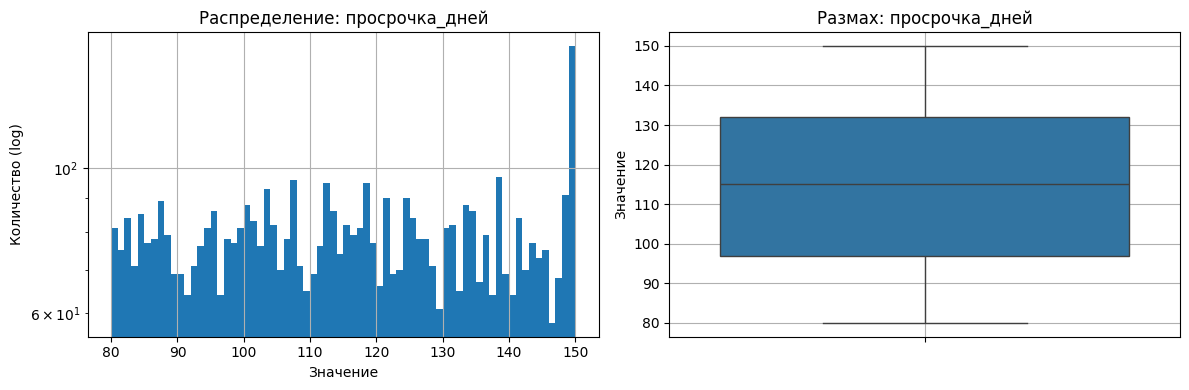

#### категориальные признаки

,ID,дата_начала_периода
count,5500,5500
unique,5500,73
top,IDF54902735,2018-12-01
freq,1,209


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54995533, IDF54964538, IDF550...",5500
1,дата_начала_периода,"[2014-12-01, 2015-06-01, 2018-03-01, 2019-09-0...",73


----------------------------------------------------------------------


### Анализ датафрейма: **транзакции**

...

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
count,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000
mean,6177.123479,3507.682295,2993.862550,9263.099506,1128.116577,3604.437043,3682.487182,5414.896895
std,8835.871514,5710.755226,4541.119582,12299.732992,1557.049316,5005.896972,5567.979383,7190.882383
min,162.910000,62.180000,67.060000,286.110000,31.900000,108.400000,81.290000,166.260000
25%,1360.880000,583.480000,611.540000,2139.480000,245.059998,824.942500,700.632500,1250.850000
50%,2659.590000,1233.110000,1224.530000,4115.385000,476.890015,1590.120000,1397.065000,2398.330000
75%,6561.467500,3642.392500,3201.612500,9287.545000,1159.520020,3866.050000,3872.412500,5413.530000
max,86939.400000,55720.690000,47969.570000,101301.950000,14261.490234,54630.190000,52987.530000,60033.550000


,Признак,Уникальные значения,Кол-во
3,MCC_5411,"[5711.1, 5824.65, 5209.51, 5765.96, 5632.11, 7...",462655
0,MCC_5300,"[3267.59, 3196.58, 3550.54, 3385.98, 3214.84, ...",423534
7,MCC_другое,"[3657.35, 3322.61, 3467.06, 3354.44, 4352.9, 5...",406485
5,MCC_5722,"[2374.78, 2187.11, 2076.54, 2231.77, 2156.67, ...",359405
6,MCC_4900,"[4059.86, 4592.26, 3605.25, 2209.39, 1519.46, ...",353656
1,MCC_5814,"[1282.11, 2443.37, 4277.72, 4530.63, 4146.65, ...",345459
2,MCC_5812,"[1457.96, 1334.2, 1463.75, 1261.4, 1405.15, 23...",335475
4,MCC_3990,"[647.43, 1067.55, 1167.95, 986.99, 640.76, 633...",221493


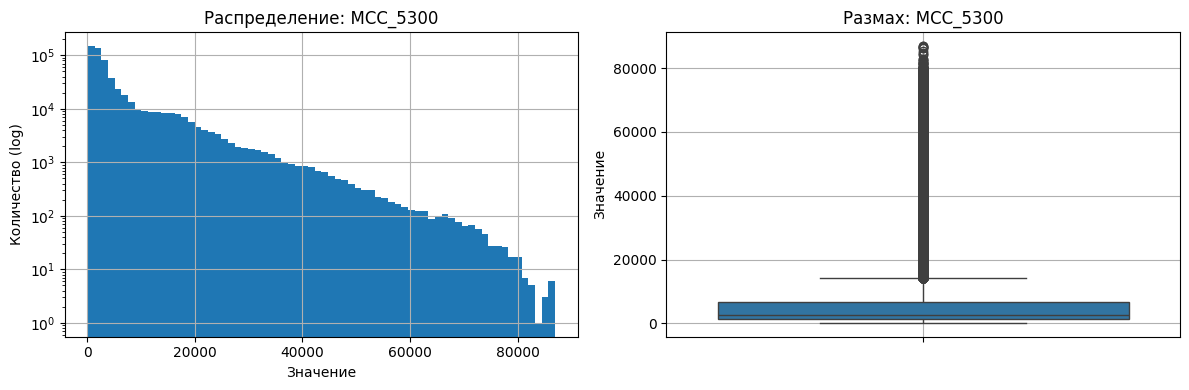

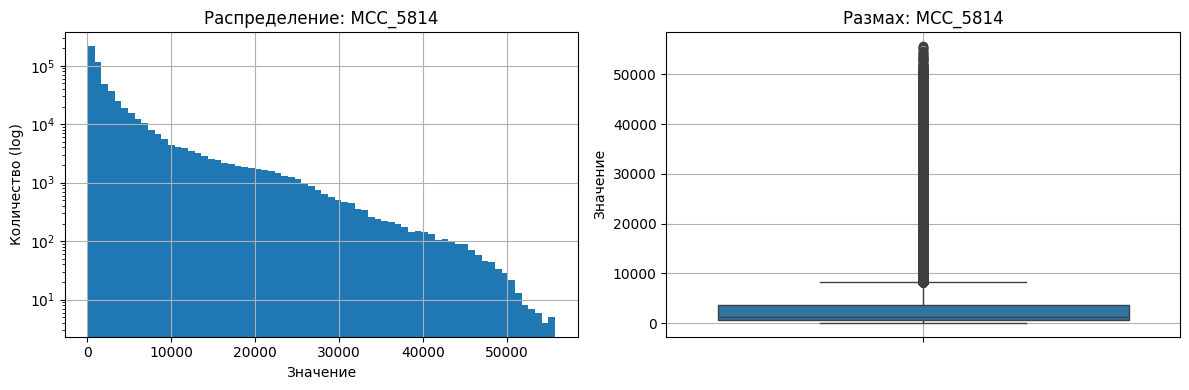

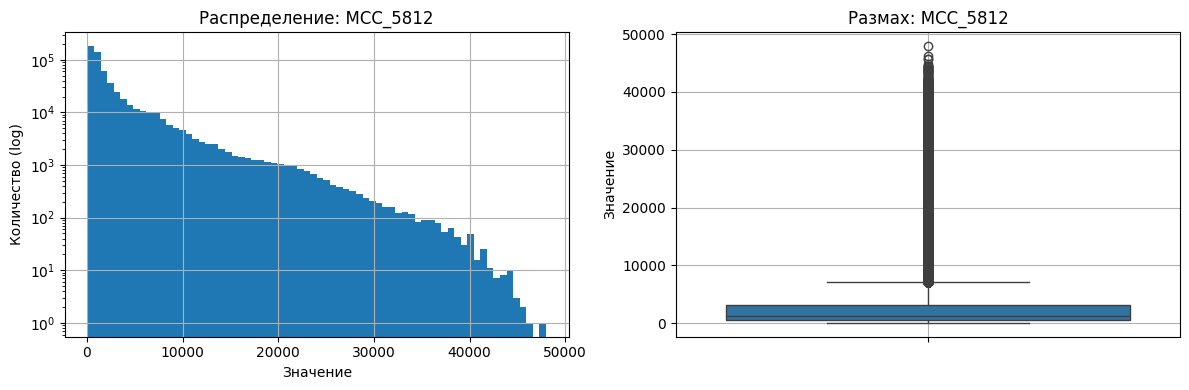

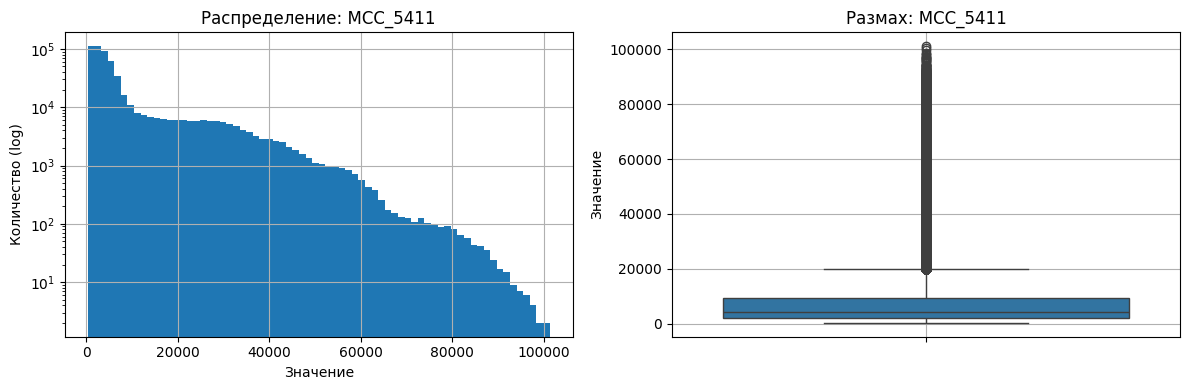

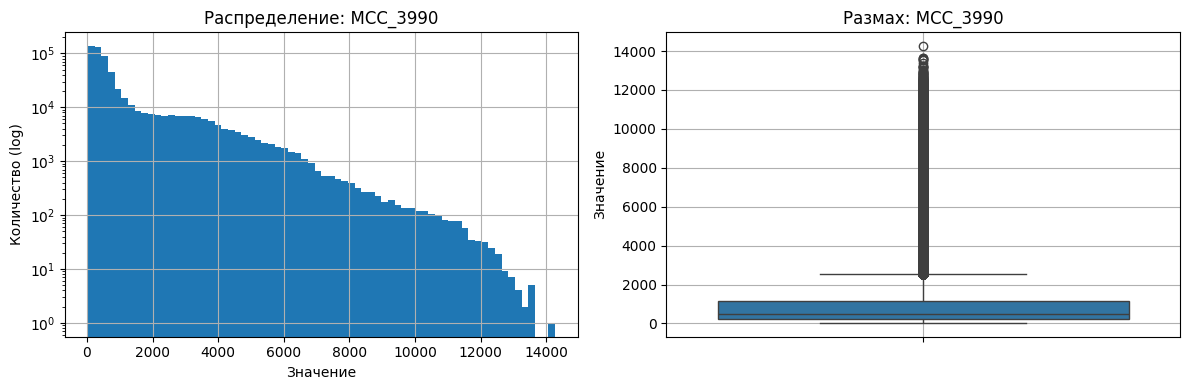

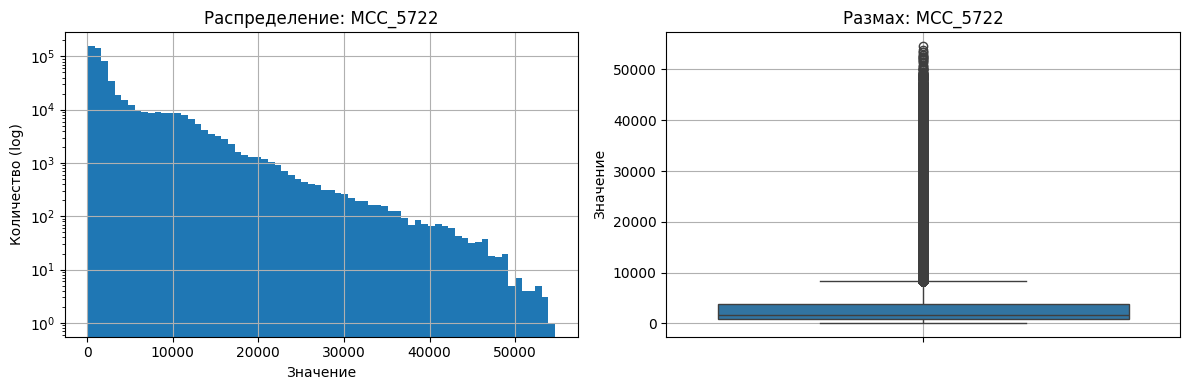

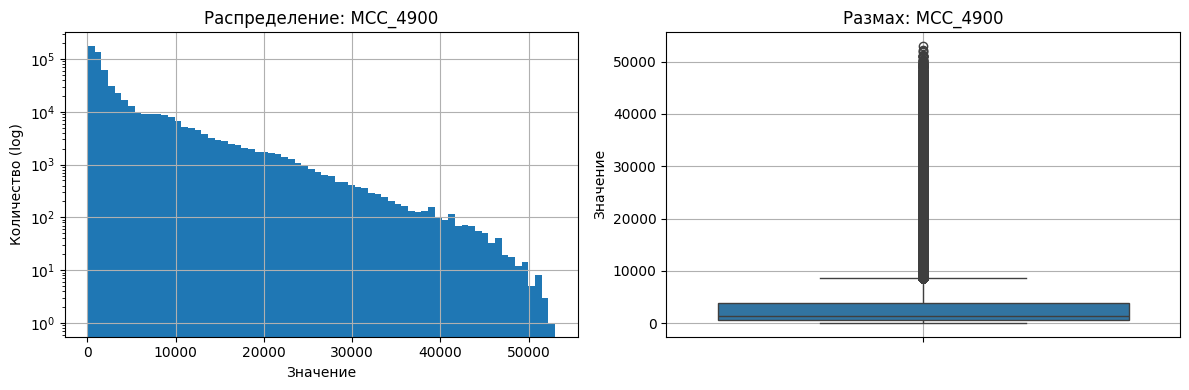

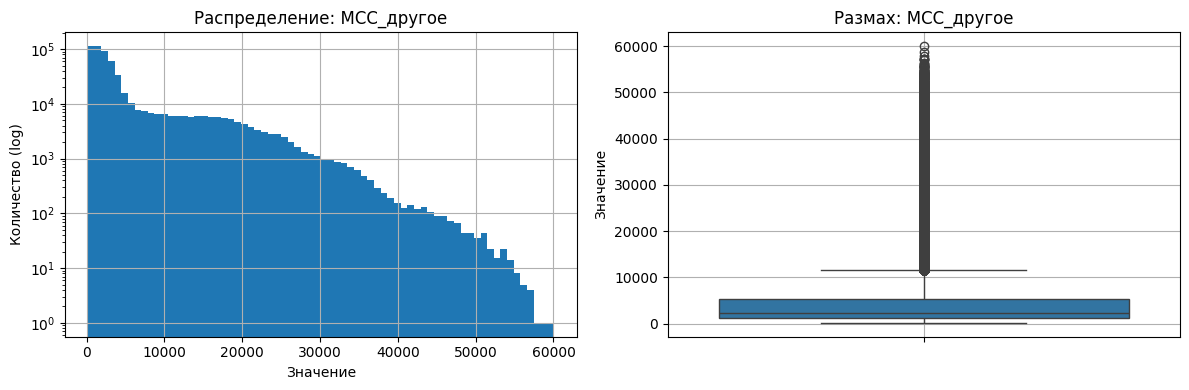

#### категориальные признаки

,ID,date
count,577494,577494
unique,13500,84
top,IDF54905698,2019-12-01
freq,84,13500


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
1,date,"[2013-05-01, 2013-06-01, 2013-07-01, 2013-08-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **описание клиента**

...

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,возраст,наличие_иждивенцев
count,13500.000000,13500.000000
mean,41.304815,0.484741
std,15.096673,0.499786
min,18.000000,0.000000
25%,28.000000,0.000000
50%,40.000000,0.000000
75%,54.000000,1.000000
max,69.000000,1.000000


,Признак,Уникальные значения,Кол-во
0,возраст,"[41, 45, 34, 40, 66, 57, 18, 27, 25, 32, 23, 5...",52
1,наличие_иждивенцев,"[1, 0]",2


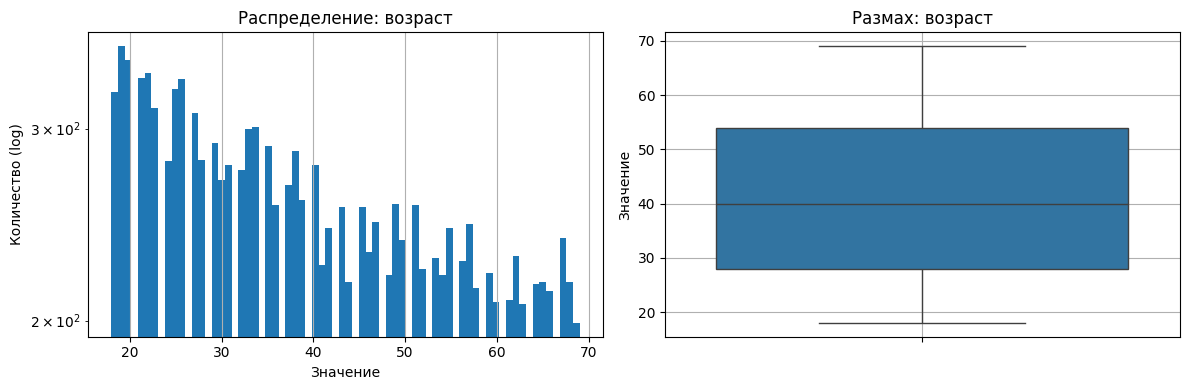

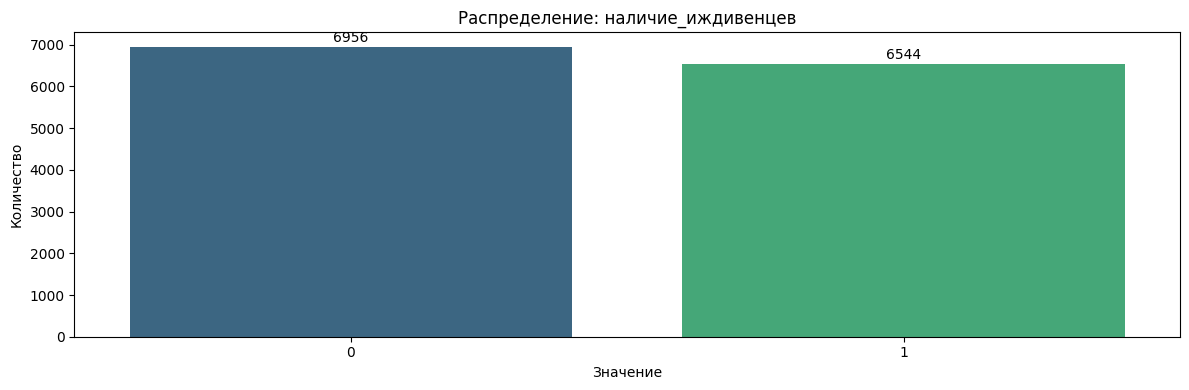

#### категориальные признаки

,ID,семейное_положение,дата_регистрации
count,13500,13500,13500
unique,13500,3,84
top,IDF55140157,нет семьи,2014-03-01
freq,1,4584,189


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
2,дата_регистрации,"[2013-05-01, 2017-12-01, 2013-11-01, 2018-08-0...",84
1,семейное_положение,"[разведённые, нет семьи, есть семья]",3


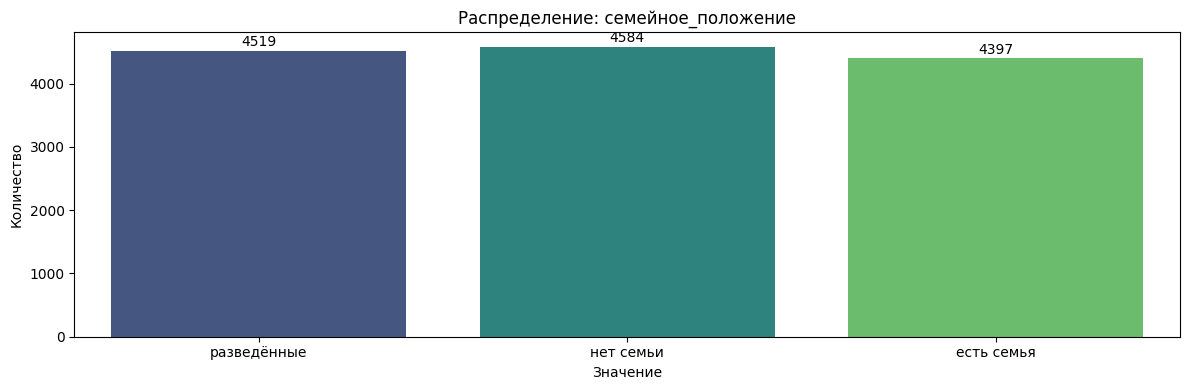

----------------------------------------------------------------------


### Анализ датафрейма: **описание кредита**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,доход,сумма_кредита
count,13500.000000,1.350000e+04
mean,79089.268593,1.993383e+06
std,40045.549462,1.061381e+06
min,15010.000000,7.500000e+04
25%,43347.000000,1.079329e+06
50%,77991.500000,2.032732e+06
75%,113615.500000,2.919236e+06
max,149988.000000,3.749400e+06


,Признак,Уникальные значения,Кол-во
1,сумма_кредита,"[1960785, 3375810, 401700, 1952655, 1107870, 3...",13140
0,доход,"[27035, 64502, 90477, 133475, 51324, 50694, 12...",12801


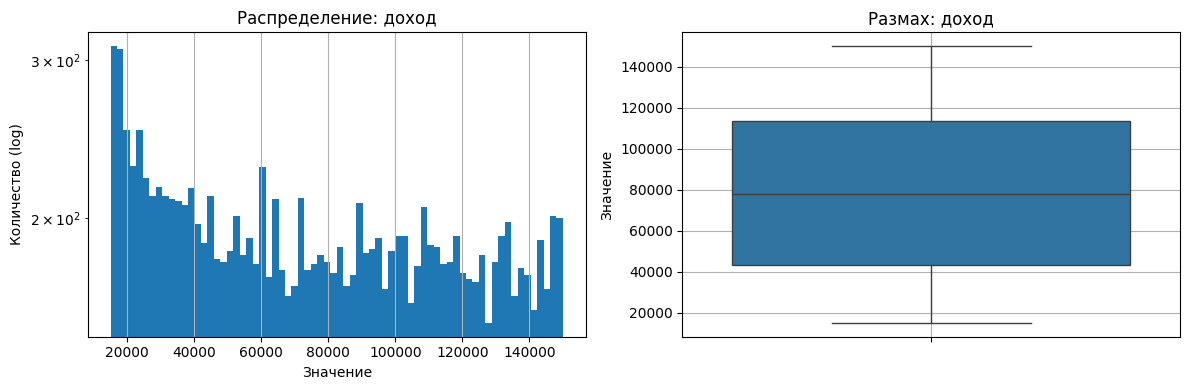

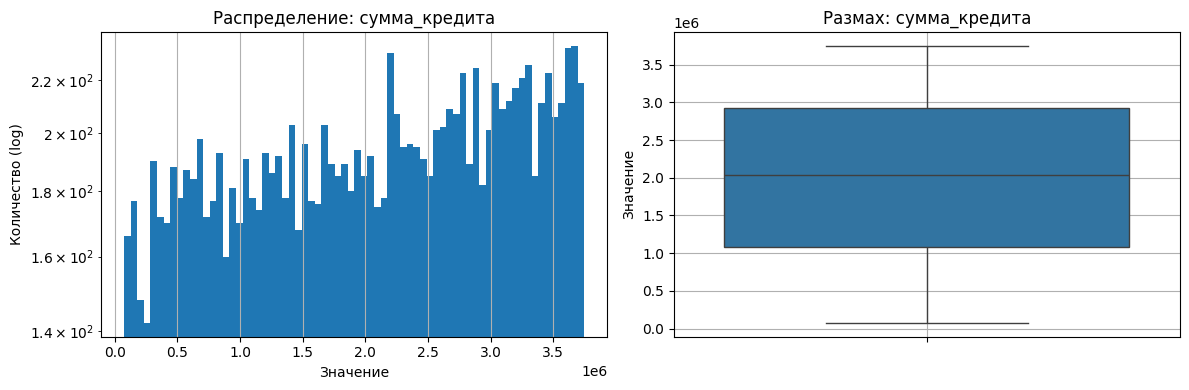

#### категориальные признаки

,ID
count,13500
unique,13500
top,IDF55140157
freq,1


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500


----------------------------------------------------------------------


### Анализ датафрейма: **наличие ипотеки**

...

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,наличие_ипотеки
count,6609.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


,Признак,Уникальные значения,Кол-во
0,наличие_ипотеки,[1],1


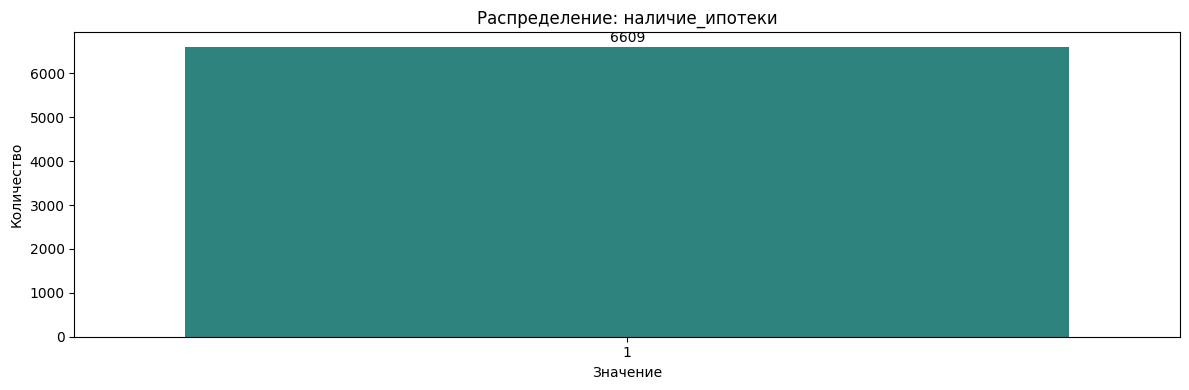

#### категориальные признаки

,ID,дата_открытия
count,6609,6609
unique,6609,84
top,IDF55151634,2018-12-01
freq,1,98


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF54896351, IDF54896367, IDF54896414, IDF548...",6609
1,дата_открытия,"[2013-03-01, 2018-01-01, 2018-02-01, 2019-02-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **кредитный рейтинг**

...

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,кредитный_рейтинг
count,577494.000000
mean,603.190961
std,64.358896
min,343.000000
25%,558.000000
50%,600.000000
75%,646.000000
max,900.000000


,Признак,Уникальные значения,Кол-во
0,кредитный_рейтинг,"[692, 688, 666, 669, 658, 656, 655, 668, 663, ...",510


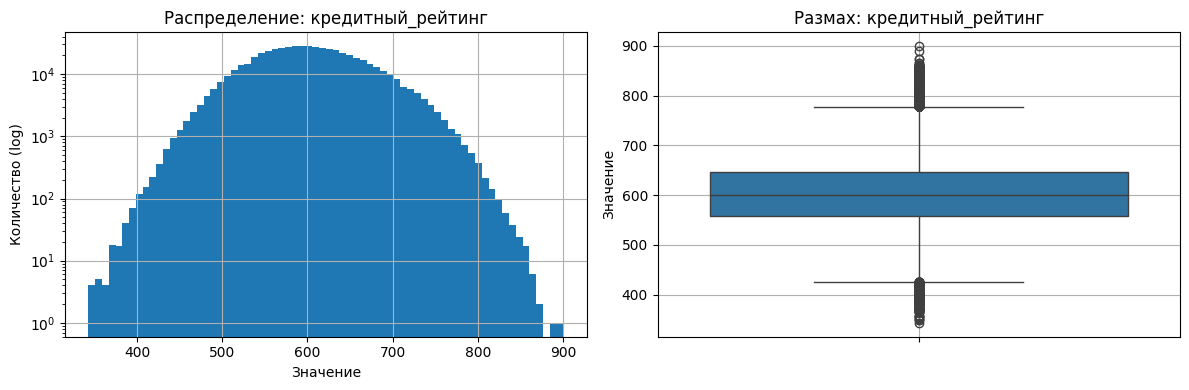

#### категориальные признаки

,ID,date
count,577494,577494
unique,13500,84
top,IDF54905698,2019-12-01
freq,84,13500


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
1,date,"[2013-05-01, 2013-06-01, 2013-07-01, 2013-08-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **макроданные**

...

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,учетная_ставка,уровень_безработицы,инфляция
count,84.000000,84.000000,84.000000
mean,8.638517,5.175000,0.527500
std,2.466112,0.409488,0.570189
min,5.500000,4.300000,-0.540000
25%,7.250000,4.900000,0.262500
50%,7.750000,5.200000,0.425000
75%,10.329545,5.500000,0.635000
max,17.000000,6.000000,3.850000


,Признак,Уникальные значения,Кол-во
2,инфляция,"[0.97, 0.56, 0.34, 0.51, 0.66, 0.42, 0.82, 0.1...",62
0,учетная_ставка,"[5.5, 7.0, 7.068182, 7.5, 7.5869565, 8.0, 9.5,...",40
1,уровень_безработицы,"[5.7, 5.8, 5.9, 5.5, 5.4, 5.3, 5.2, 5.1, 5.6, ...",18


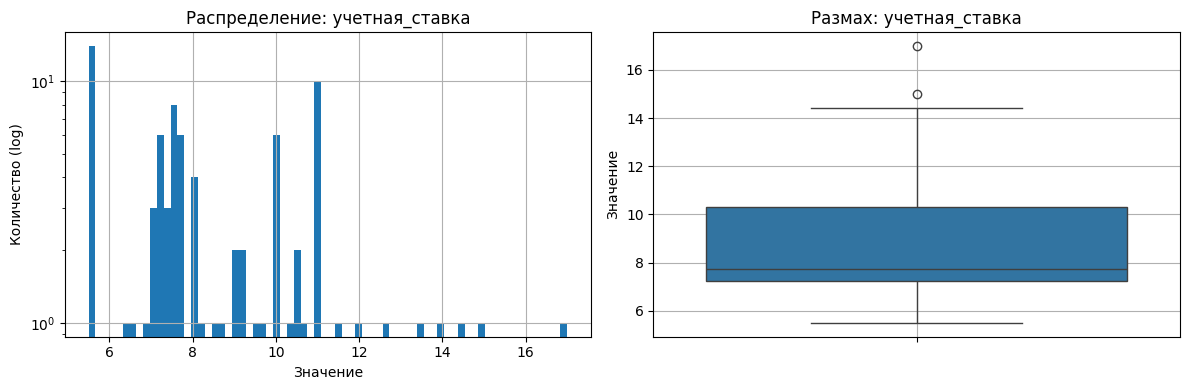

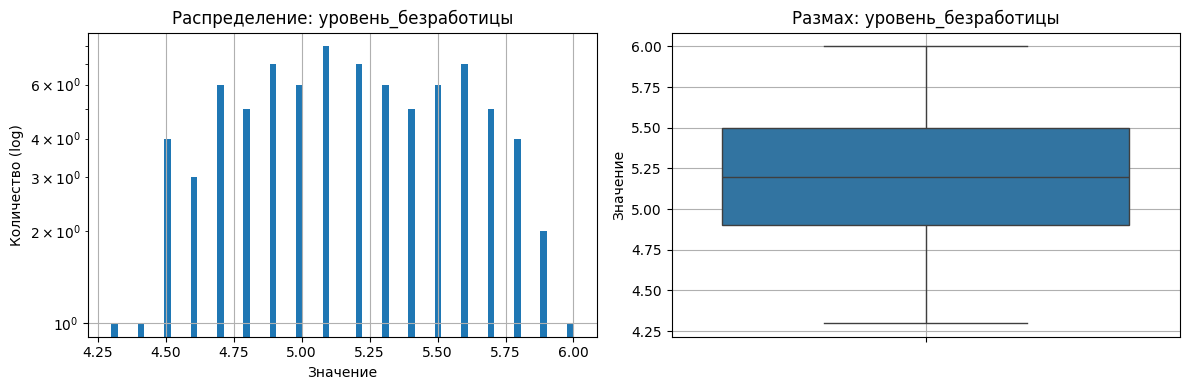

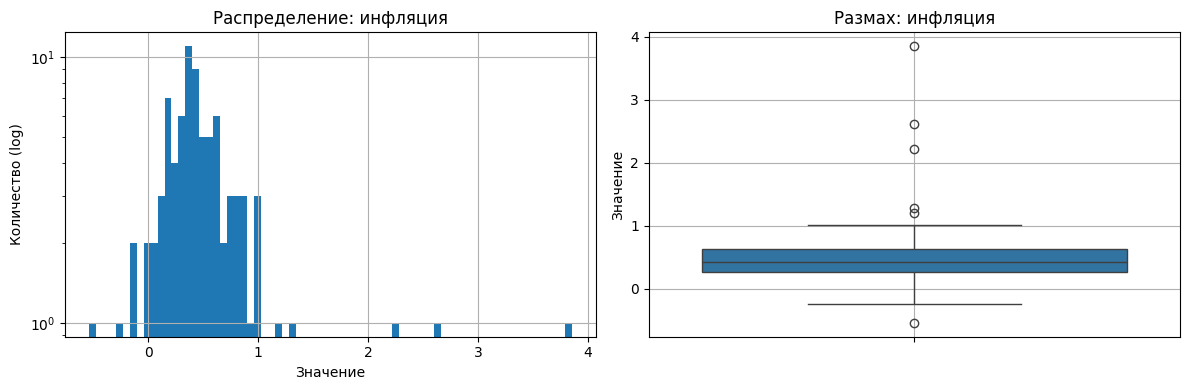

#### категориальные признаки

,date
count,84
unique,84
top,2013-01-01
freq,1


,Признак,Уникальные значения,Кол-во
0,date,"[2013-01-01, 2013-02-01, 2013-03-01, 2013-04-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **когортная сетка**

...

Отсутствуют



#### категориальные признаки

,ID,score_date
count,577494,577494
unique,13500,84
top,IDF54905698,2019-12-01
freq,84,13500


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
1,score_date,"[2013-05-01, 2013-06-01, 2013-07-01, 2013-08-0...",84


----------------------------------------------------------------------


In [11]:
tables = [
    (loan_payment_credit, 'кредитный платеж'),
    (transactions, 'транзакции'),
    (client_description, 'описание клиента'),
    (credit_description, 'описание кредита'),
    (mortgage_presence, 'наличие ипотеки'),
    (credit_rating, 'кредитный рейтинг'),
    (macro_data, 'макроданные'),
    (cohort_grid, 'когортная сетка')
]

for table, name in tables:
    primary_analysis(table, name)

Вывод: технические пропуски и явные дубликаты отсутствуют во всех таблицах. Выборка включает 13 500 уникальных клиентов с равномерным распределением по возрасту (от 18 до 69 лет) и семейному статусу, при этом около 49% из них (6609 человек) имеют ипотеку. Когортная сетка подтверждает полную структуру временных рядов: для каждого из 13 500 id представлено ровно 84 ежемесячных наблюдения, что формирует массив из 577 494 записей для анализа динамики транзакций и рейтинга. В транзакционных данных по всем MCC-кодам выявлены экстремальные правосторонние выбросы (максимумы до 101 тыс. при средних значениях 6–9 тыс.), в то время как кредитный рейтинг (от 343 до 900) распределен нормально. Целевые события дефолта (5500 записей) зафиксированы строго в интервале просрочки от 80 до 150 дней, а макроэкономический фон за 7 лет отражает существенные колебания учетной ставки от 5,5% до 17%, и периоды инфляции до 4%, и дефляции (-0.54%), колебания безработицы в пределах 4,3–6,0%, так что модель сможет учесть влияние кризисов на платежеспособность.

## Объединение таблиц & Создание новых признаков

Получение информации по одному пользователю для сверки итоговой таблицы

In [12]:
id = 'IDF54995533'

display(loan_payment_credit[loan_payment_credit['ID'] == id])
display(transactions[transactions['ID'] == id])
display(client_description[client_description['ID'] == id])
display(credit_description[credit_description['ID'] == id])
display(mortgage_presence[mortgage_presence['ID'] == id])
display(credit_rating[credit_rating['ID'] == id].shift(1))
display(cohort_grid[cohort_grid['ID'] == id])

,ID,дата_начала_периода,просрочка_дней
1,IDF54995533,2015-06-01,121


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
105,IDF54995533,2013-11-01,10462.39,3953.09,4397.23,18684.95,1940.729980,7065.21,12791.49,10011.65
106,IDF54995533,2013-12-01,10654.05,9485.75,4732.57,18766.35,3256.929932,7294.09,13692.72,10987.01
107,IDF54995533,2014-01-01,11271.94,13135.86,4566.76,17635.32,3928.520020,7487.61,12315.87,11105.60
108,IDF54995533,2014-02-01,11395.93,16727.66,4359.29,18831.08,3428.419922,6640.08,8793.45,10951.81
109,IDF54995533,2014-03-01,11954.18,13973.07,4537.26,18763.97,2199.020020,7118.18,5052.48,14473.56
...,...,...,...,...,...,...,...,...,...,...
174,IDF54995533,2019-08-01,3225.93,548.76,1075.09,2701.34,312.709991,1261.00,746.07,1816.10
175,IDF54995533,2019-09-01,2150.58,549.70,597.93,2912.24,315.250000,1851.32,772.65,1664.07
176,IDF54995533,2019-10-01,1540.66,541.35,597.93,2317.04,267.809998,2053.63,672.70,1480.44
177,IDF54995533,2019-11-01,1324.59,508.24,615.50,2491.62,287.619995,938.25,1663.38,1418.46


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
2,IDF54995533,34,разведённые,1,2013-11-01


,ID,доход,сумма_кредита
2,IDF54995533,90477,401700


,ID,дата_открытия,наличие_ипотеки
2559,IDF54995533,2013-11-01,1


,ID,date,кредитный_рейтинг
105,None,None,NaN
106,IDF54995533,2013-11-01,686.0
107,IDF54995533,2013-12-01,662.0
108,IDF54995533,2014-01-01,648.0
109,IDF54995533,2014-02-01,651.0
...,...,...,...
174,IDF54995533,2019-07-01,547.0
175,IDF54995533,2019-08-01,543.0
176,IDF54995533,2019-09-01,542.0
177,IDF54995533,2019-10-01,543.0


,ID,score_date
105,IDF54995533,2013-11-01
106,IDF54995533,2013-12-01
107,IDF54995533,2014-01-01
108,IDF54995533,2014-02-01
109,IDF54995533,2014-03-01
...,...,...
174,IDF54995533,2019-08-01
175,IDF54995533,2019-09-01
176,IDF54995533,2019-10-01
177,IDF54995533,2019-11-01


Формирование итоговой таблицы

In [13]:
def merge_tables(
    cohort_grid, 
    loan_payment_credit, 
    client_description, 
    credit_description,
    mortgage_presence, 
    macro_data,
    credit_rating,
    transactions
):
    initial_len = len(cohort_grid)
    
    for df, col in [
        (cohort_grid, 'score_date'),
        (loan_payment_credit, 'дата_начала_периода'),
        (client_description, 'дата_регистрации'),
        (mortgage_presence, 'дата_открытия'),
        (macro_data, 'date'),
        (credit_rating, 'date'),
        (transactions, 'date'),
    ]:
        df[col] = pd.to_datetime(df[col])

    first_defaults = (
        loan_payment_credit[loan_payment_credit['просрочка_дней'] >= 90]
        .sort_values(["ID", "дата_начала_периода"])
        .drop_duplicates("ID", keep="first")
        [['ID', 'дата_начала_периода']]
    )

    df = pd.merge(cohort_grid, first_defaults, on='ID', how='left')

    df['target'] = (
        (df['дата_начала_периода'] >= df['score_date']) & 
        (df['дата_начала_периода'] < df['score_date'] + pd.Timedelta(days=365))
    ).astype(int)

    df = df[~(df['дата_начала_периода'] < df['score_date'])].copy()
    after_filter_len = len(df)

    for tbl in [client_description, credit_description, mortgage_presence]:
        df = df.merge(tbl, on='ID', how='left')

    df['client_tenure_days'] = (df['score_date'] - df['дата_регистрации']).dt.days.fillna(-1)

    df['mortgage_age_days'] = (df['score_date'] - df['дата_открытия']).dt.days
    no_mortgage_mask = (df['дата_открытия'].isna()) | (df['дата_открытия'] >= df['score_date'])
    df.loc[no_mortgage_mask, 'mortgage_age_days'] = -1
    df['наличие_ипотеки'] = (~no_mortgage_mask).astype(int)

    df = df.sort_values('score_date')

    df = pd.merge_asof(
        df, macro_data.sort_values('date'),
        left_on='score_date', right_on='date',
        direction='backward', allow_exact_matches=False
    ).drop(columns=['date'])

    for tbl in [credit_rating, transactions]:
        df = pd.merge_asof(
            df, tbl.sort_values('date'),
            left_on='score_date', right_on='date', by='ID',
            direction='backward', allow_exact_matches=False
    ).drop(columns=['date'])
    df['кредитный_рейтинг'] = df['кредитный_рейтинг'].fillna(-1)

    mcc_cols = [col for col in df.columns if 'MCC_' in col]
    df[mcc_cols] = df[mcc_cols].fillna(0)
    df['total_mcc_spent'] = df[mcc_cols].sum(axis=1)
    
    df['leisure_to_base_ratio'] = (df['MCC_5814'] + df['MCC_5812']) / (df['MCC_5411'] + 1e-9)

    df['loan_to_income_ratio'] = df['сумма_кредита'] / (df['доход'] + 1e-9)

    df['spend_drop_ratio'] = df['total_mcc_spent'] / (df.groupby('ID')['total_mcc_spent'].cummax() + 1e-9)

    df = df.drop(columns=['дата_начала_периода', 'дата_открытия', 'дата_регистрации'])
    df = df.dropna()

    final_len = len(df)
    print(f"Начальный размер: {initial_len}")
    final_without_default = initial_len - after_filter_len + final_len
    print(f'После соединения всех таблиц без фильтра дефолтов: {final_without_default} (разница с исходным {initial_len - final_without_default} ({(1 - final_without_default / initial_len) * 100:.2f}%))')
    print(f"После фильтра дефолтов: {after_filter_len}")
    print(f"Итоговый размер: {final_len}")
    print(f"Потеряно строк: {initial_len - final_len} ({(1 - final_len / initial_len) * 100:.2f}%)")

    return df

In [14]:
df = merge_tables(
    cohort_grid, 
    loan_payment_credit, 
    client_description, 
    credit_description,
    mortgage_presence,
    macro_data,
    credit_rating,
    transactions
)

Начальный размер: 577494
После соединения всех таблиц без фильтра дефолтов: 577342 (разница с исходным 152 (0.03%))
После фильтра дефолтов: 438379
Итоговый размер: 438227
Потеряно строк: 139267 (24.12%)


In [15]:
show_missing_stats(df)

'Пропусков в данных нет'

In [16]:
df.head()

,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки,client_tenure_days,mortgage_age_days,учетная_ставка,уровень_безработицы,инфляция,кредитный_рейтинг,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,total_mcc_spent,leisure_to_base_ratio,loan_to_income_ratio,spend_drop_ratio
152,IDF55114026,2013-02-01,0,65,нет семьи,0,96507,2391435,0,0,-1.0,5.5,5.7,0.97,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,24.779912,0.0
153,IDF54976809,2013-02-01,0,26,нет семьи,0,60433,3297510,0,31,-1.0,5.5,5.7,0.97,571.0,7213.61,2824.62,2959.81,12713.93,1311.010010,4816.61,8975.66,7689.17,48504.420010,0.454968,54.564725,1.0
154,IDF55052704,2013-02-01,0,34,нет семьи,0,61885,3640665,0,31,-1.0,5.5,5.7,0.97,806.0,6762.73,2505.00,2943.34,12277.45,1425.709961,4216.30,8098.78,6419.73,44649.039961,0.443768,58.829523,1.0
155,IDF55060576,2013-02-01,0,24,разведённые,0,143372,1269390,0,31,-1.0,5.5,5.7,0.97,784.0,17812.70,6539.69,7365.39,29840.35,3331.709961,11309.75,20508.71,17894.33,114602.629961,0.465982,8.853821,1.0
156,IDF54960225,2013-02-01,1,57,нет семьи,0,136215,816345,0,0,-1.0,5.5,5.7,0.97,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,5.993062,0.0


In [17]:
df[df['ID'] == 'IDF54995533']

,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки,client_tenure_days,mortgage_age_days,учетная_ставка,уровень_безработицы,инфляция,кредитный_рейтинг,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,total_mcc_spent,leisure_to_base_ratio,loan_to_income_ratio,spend_drop_ratio
9057,IDF54995533,2013-11-01,0,34,разведённые,1,90477,401700,0,0,-1.0,5.500000,5.4,0.57,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,4.439802,0.000000
10710,IDF54995533,2013-12-01,0,34,разведённые,1,90477,401700,1,30,30.0,5.500000,5.5,0.56,686.0,10462.39,3953.09,4397.23,18684.95,1940.729980,7065.21,12791.49,10011.65,69306.739980,0.446901,4.439802,1.000000
14425,IDF54995533,2014-01-01,0,34,разведённые,1,90477,401700,1,61,61.0,5.500000,5.6,0.51,662.0,10654.05,9485.75,4732.57,18766.35,3256.929932,7294.09,13692.72,10987.01,78869.469932,0.757650,4.439802,1.000000
15871,IDF54995533,2014-02-01,0,34,разведённые,1,90477,401700,1,92,92.0,5.500000,5.6,0.59,648.0,11271.94,13135.86,4566.76,17635.32,3928.520020,7487.61,12315.87,11105.60,81447.480020,1.003816,4.439802,1.000000
17261,IDF54995533,2014-03-01,0,34,разведённые,1,90477,401700,1,120,120.0,5.500000,5.5,0.70,651.0,11395.93,16727.66,4359.29,18831.08,3428.419922,6640.08,8793.45,10951.81,81127.719922,1.119795,4.439802,0.996074
19757,IDF54995533,2014-04-01,0,34,разведённые,1,90477,401700,1,151,151.0,7.000000,5.4,1.02,662.0,11954.18,13973.07,4537.26,18763.97,2199.020020,7118.18,5052.48,14473.56,78071.720020,0.986483,4.439802,0.958553
24148,IDF54995533,2014-05-01,0,34,разведённые,1,90477,401700,1,181,181.0,7.068182,4.9,0.90,660.0,10832.39,7839.41,6966.39,26254.69,2040.199951,6908.19,5242.03,16413.95,82497.249951,0.563930,4.439802,1.000000
24358,IDF54995533,2014-06-01,0,34,разведённые,1,90477,401700,1,212,212.0,7.500000,5.0,0.90,655.0,13916.97,4409.44,11558.86,29463.69,2146.669922,7423.89,6022.73,14452.58,89394.829922,0.541965,4.439802,1.000000
29736,IDF54995533,2014-07-01,1,34,разведённые,1,90477,401700,1,242,242.0,7.500000,5.1,0.62,662.0,24418.89,4466.03,15256.66,28450.04,2504.550049,7844.90,6302.32,12907.27,102150.660049,0.693239,4.439802,1.000000
30985,IDF54995533,2014-08-01,1,34,разведённые,1,90477,401700,1,273,273.0,7.586957,5.0,0.49,671.0,27109.15,4489.26,14670.41,21647.59,2358.870117,8511.22,6421.77,12110.11,97318.380117,0.885072,4.439802,0.952695


Итоговая витрина сформирована с минимальной технической потерей данных: на этапе объединения таблиц отсеяно всего 152 строки (0.03%). Сокращение выборки с 577 494 до 438 227 строк (общая потеря 24.12%) является обоснованным, так как вызвано исключением клиентов, уже находившихся в дефолте на момент скоринга. Логика обработки пропусков в таблице построена на принципе исключения утечек из будущего и сохранении физического смысла данных: транзакции заполнены нулями, так как отсутствие записи означает отсутствие трат; стаж клиента, возраст ипотеки и кредитный рейтинг заполнены значением -1, чтобы модель могла четко отличить отсутствие истории или продукта от новых записей с нулевым стажем. Пропуски в макроданных (0.03%), возникшие из-за временного смещения, были удалены через dropna(), так как любой метод их заполнения (например, значениями из следующего месяца) привел бы к использованию будущей информации при прогнозировании. В результате получена чистая, обогащенная признаками таблица, полностью готовая к обучению.

## Анализ итоговой таблицы

In [18]:
eda_df = df.copy()

eda_df = eda_df.drop(columns='ID')

In [19]:
target_desc = eda_df['target'].describe()

target_desc

,target
count,438227.000000
mean,0.112622
std,0.316131
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


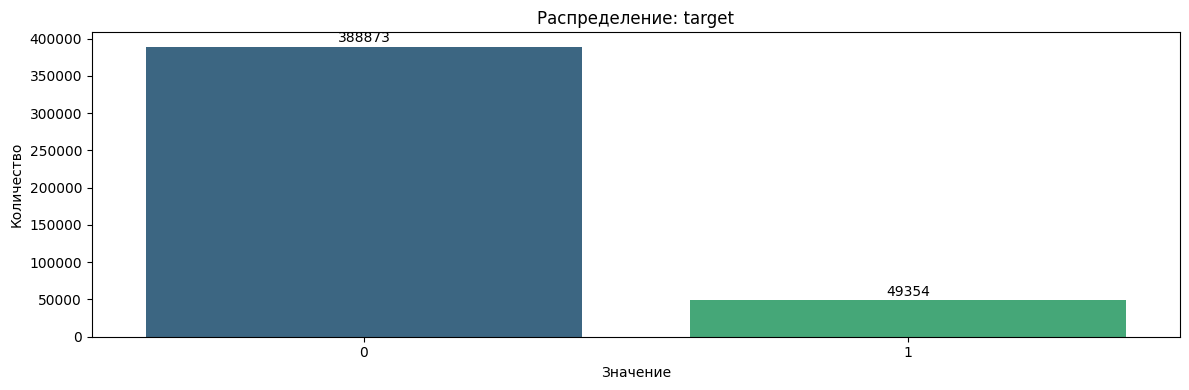

In [20]:
create_cat_plot(eda_df, 'target')

In [21]:
target_counts = eda_df['target'].value_counts()

print(f'Дефолта не было: {target_counts[0] / target_desc['count'] * 100:.0f}%')
print(f'Дефолт был: {target_counts[1] / target_desc['count'] * 100:.0f}%')

Дефолта не было: 89%
Дефолт был: 11%


Явный дисбаланс классов в сторону клиентов банка, у которых не было дефолта. Соотношение почти 1:10.

### Анализ датафрейма: **Итоговый dataframe**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,target,возраст,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки,client_tenure_days,mortgage_age_days,учетная_ставка,уровень_безработицы,инфляция,кредитный_рейтинг,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,total_mcc_spent,leisure_to_base_ratio,loan_to_income_ratio,spend_drop_ratio
count,438227.000000,438227.000000,438227.000000,438227.000000,4.382270e+05,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000
mean,0.112622,42.992518,0.496316,80756.421270,1.934256e+06,0.479859,754.620993,374.458780,8.783223,5.060837,0.435474,592.315711,7400.777174,4236.589960,3586.688299,11127.042053,1358.949219,4314.758092,4450.074883,6507.159926,42982.039939,0.685651,34.797899,0.419565
std,0.316131,15.156725,0.499987,39664.778998,1.064197e+06,0.499595,603.754275,569.346781,2.049460,0.411168,0.514095,123.828175,9786.669938,6353.834742,5044.821627,13547.341734,1717.734741,5534.501371,6170.295785,7919.333098,51422.979338,0.247870,35.407643,0.427034
min,0.000000,18.000000,0.000000,15010.000000,7.500000e+04,0.000000,0.000000,-1.000000,5.500000,4.300000,-0.540000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.506239,0.000000
25%,0.000000,30.000000,0.000000,45639.000000,1.013505e+06,0.000000,244.000000,-1.000000,7.437500,4.700000,0.200000,559.000000,1536.525000,650.900000,685.230000,2433.155000,277.885010,933.695000,788.680000,1420.940000,9544.310013,0.488540,12.462726,0.079841
50%,0.000000,43.000000,0.000000,80473.000000,1.939365e+06,0.000000,608.000000,-1.000000,7.750000,5.000000,0.360000,606.000000,3163.100000,1561.610000,1476.140000,4842.910000,565.659973,1876.010000,1691.880000,2824.440000,18812.110012,0.657954,23.853015,0.113963
75%,0.000000,56.000000,1.000000,115066.000000,2.851905e+06,1.000000,1185.000000,607.000000,10.000000,5.400000,0.560000,655.000000,9637.990000,4961.225000,4447.890000,15687.820000,1886.434998,5849.555000,5717.115000,9202.025000,61495.605022,0.902249,42.838411,0.973246
max,1.000000,69.000000,1.000000,149988.000000,3.749400e+06,1.000000,2525.000000,2525.000000,17.000000,6.000000,3.850000,900.000000,86939.400000,55720.690000,47969.570000,101301.950000,14261.490234,54630.190000,52987.530000,60033.550000,309029.080059,1.383141,242.970580,1.000000


,Признак,Уникальные значения,Кол-во
21,leisure_to_base_ratio,"[0.0, 0.45496789741642, 0.4437680462962224, 0....",424880
20,total_mcc_spent,"[0.0, 48504.42000976563, 44649.0399609375, 114...",424638
15,MCC_5411,"[0.0, 12713.93, 12277.45, 29840.35, 28906.28, ...",372977
12,MCC_5300,"[0.0, 7213.61, 6762.73, 17812.7, 16010.97, 190...",352363
19,MCC_другое,"[0.0, 7689.17, 6419.73, 17894.33, 16282.1, 191...",343722
23,spend_drop_ratio,"[0.0, 0.9999999999999795, 0.9999999999999777, ...",329548
17,MCC_5722,"[0.0, 4816.61, 4216.3, 11309.75, 10893.44, 115...",315407
18,MCC_4900,"[0.0, 8975.66, 8098.78, 20508.71, 19694.13, 23...",312075
13,MCC_5814,"[0.0, 2824.62, 2505.0, 6539.69, 6518.82, 6663....",305340
14,MCC_5812,"[0.0, 2959.81, 2943.34, 7365.39, 6361.28, 8206...",299144


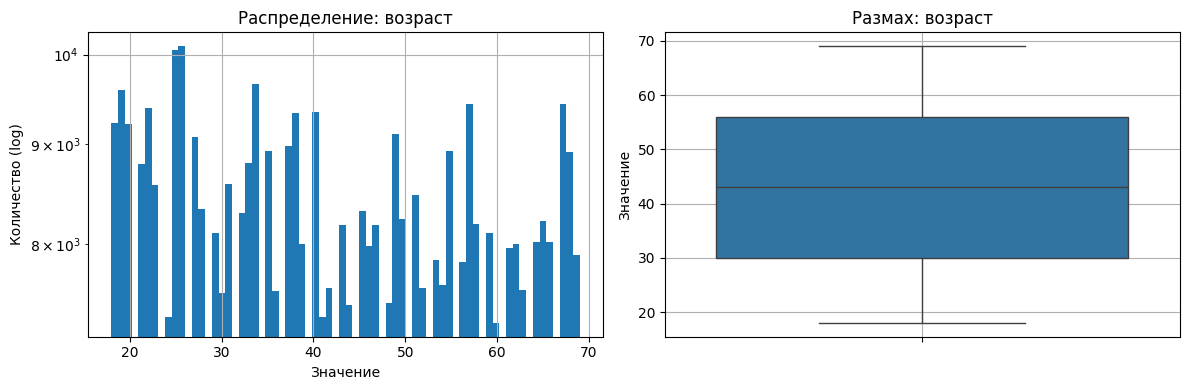

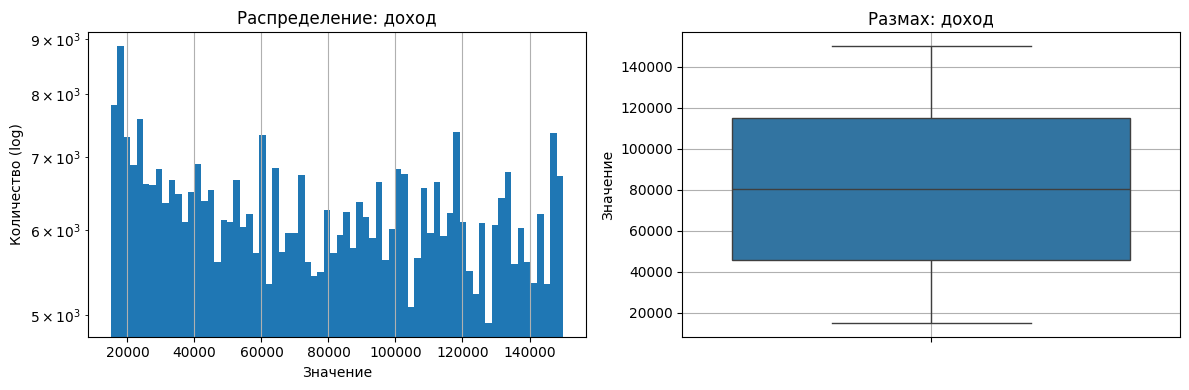

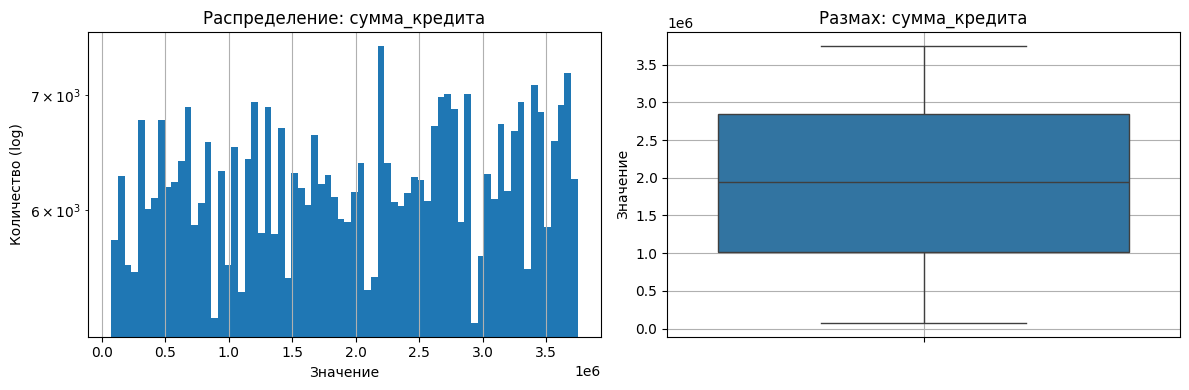

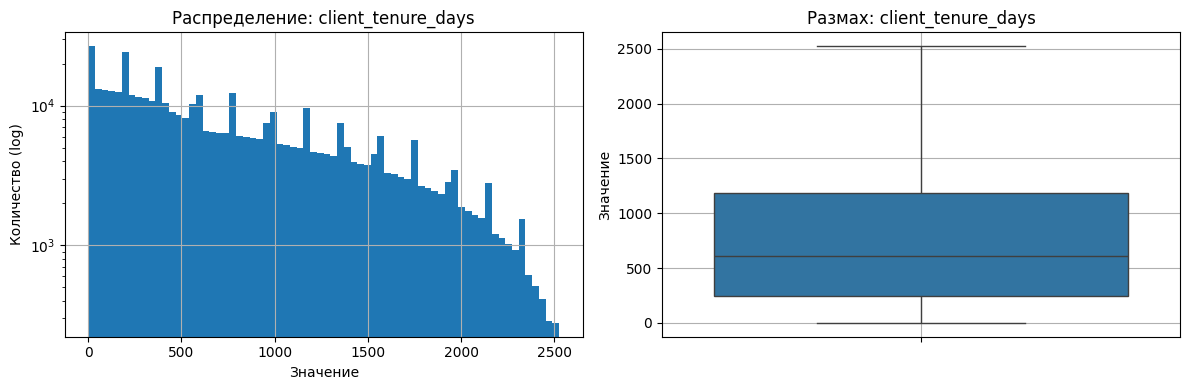

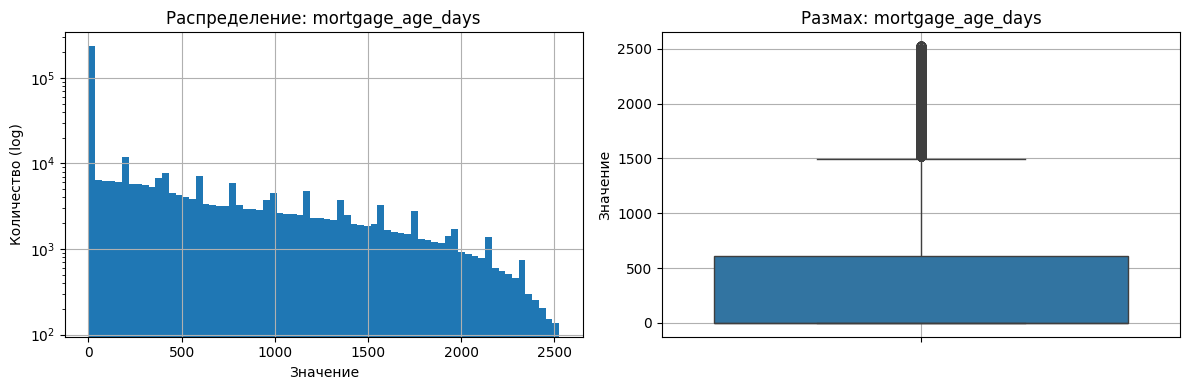

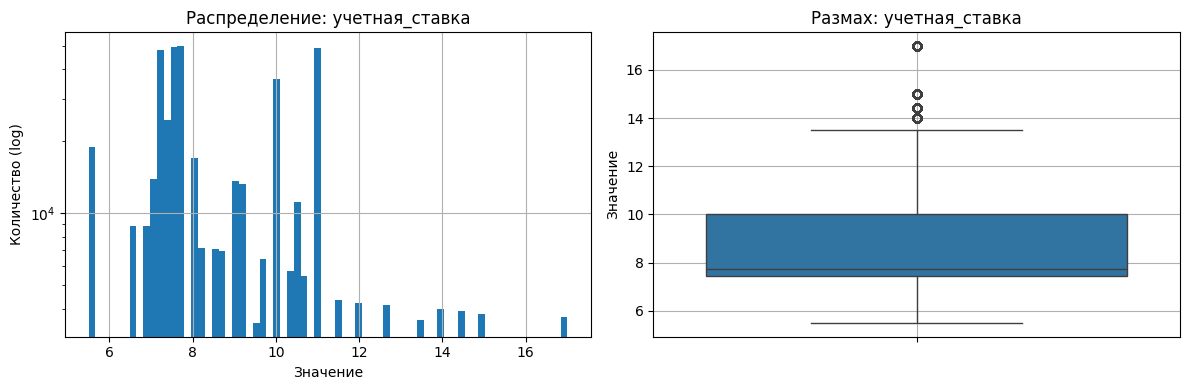

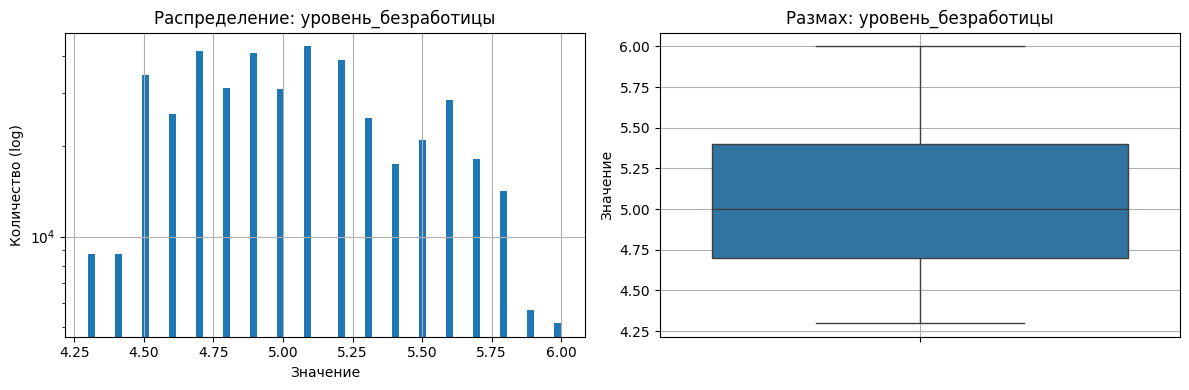

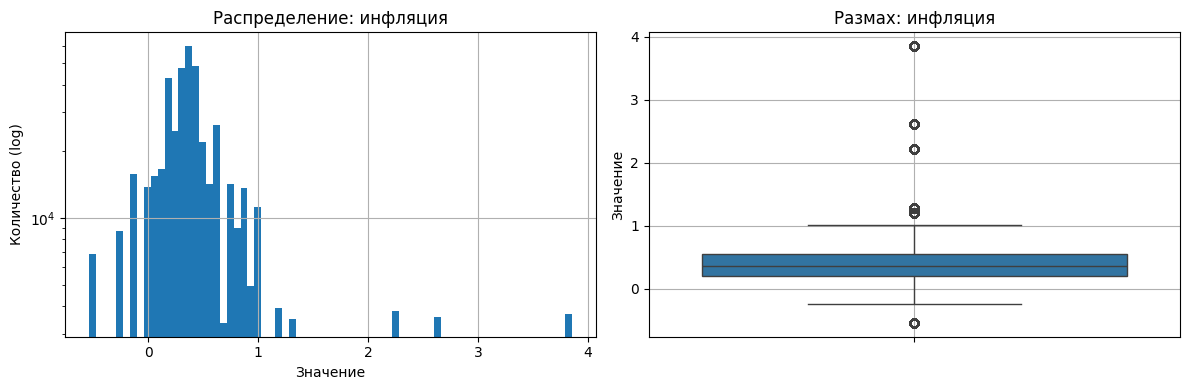

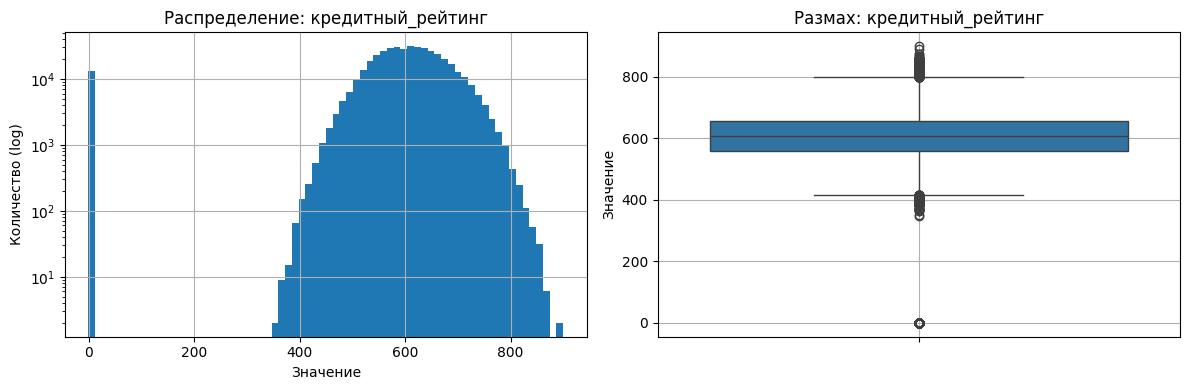

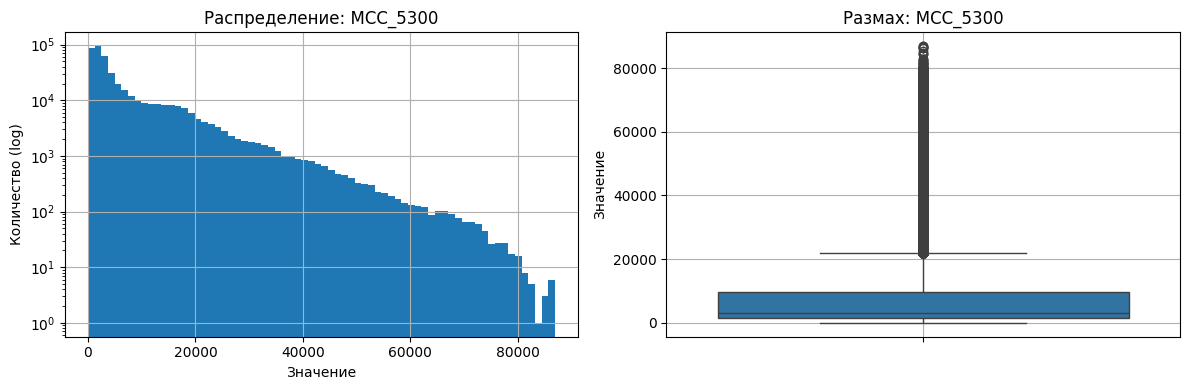

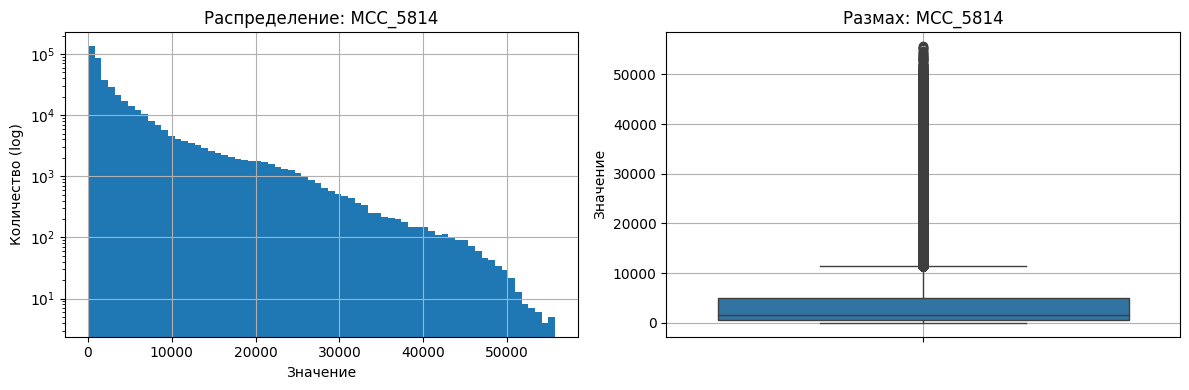

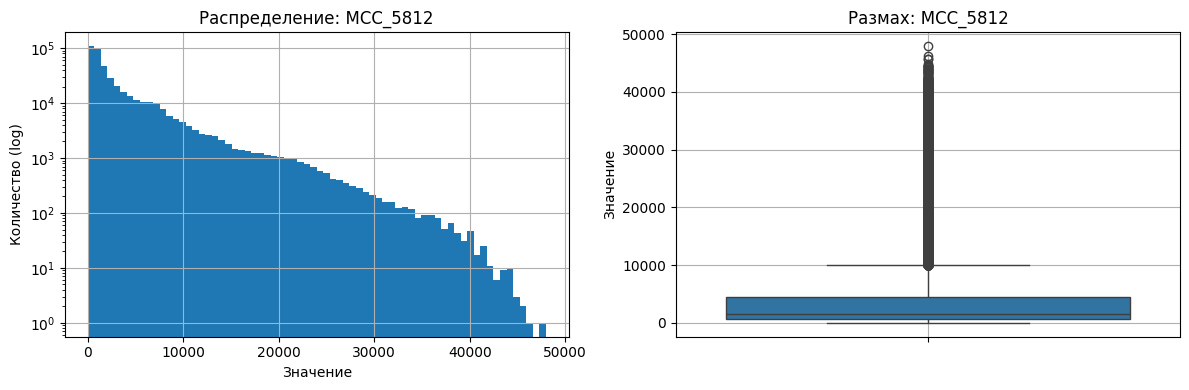

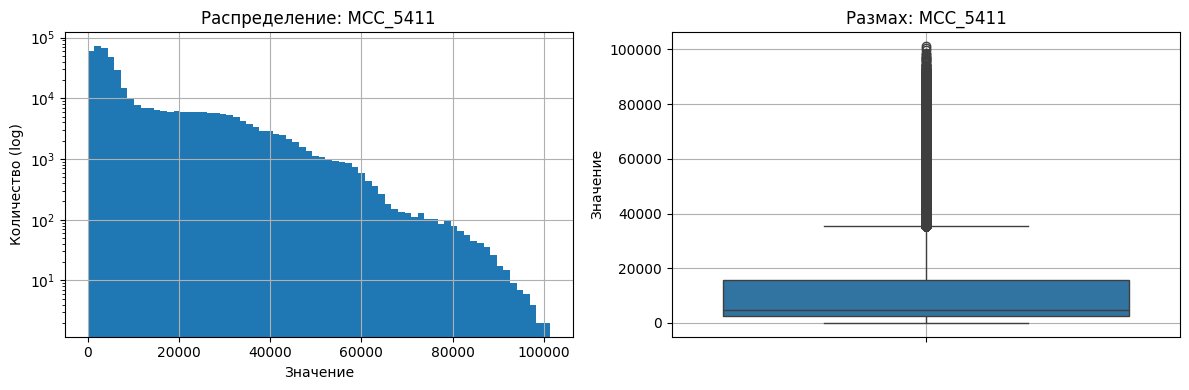

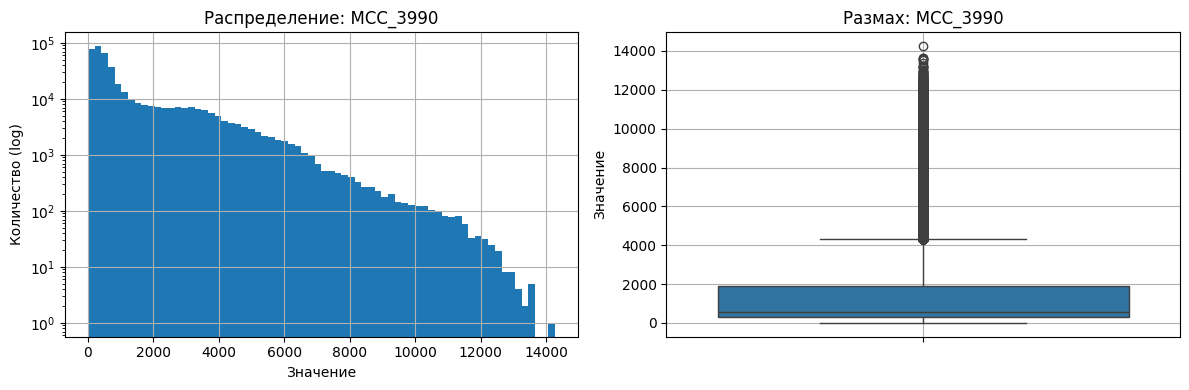

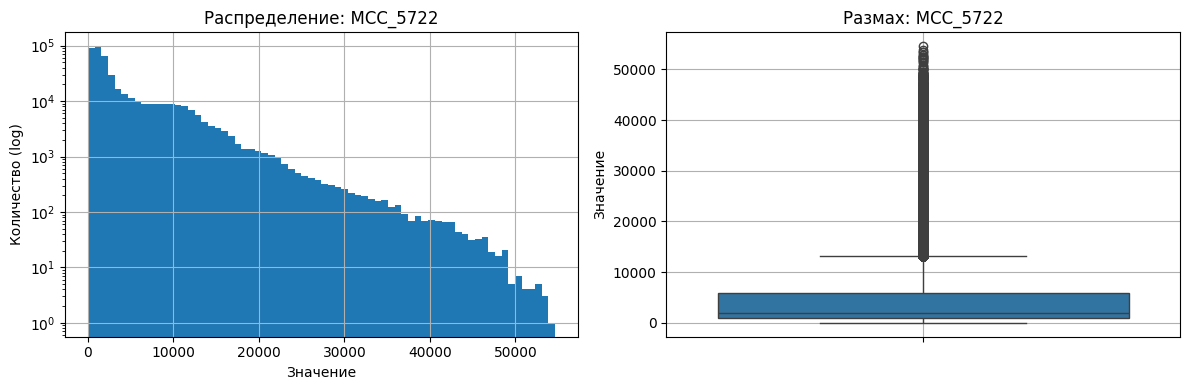

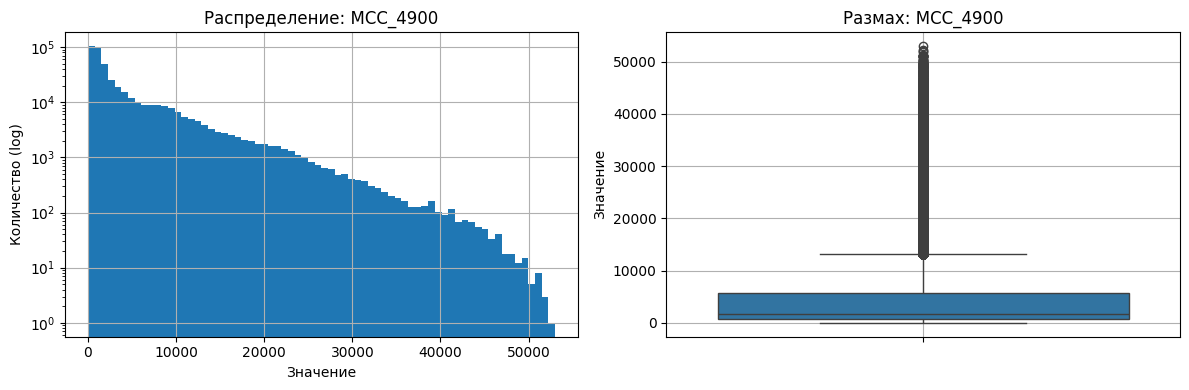

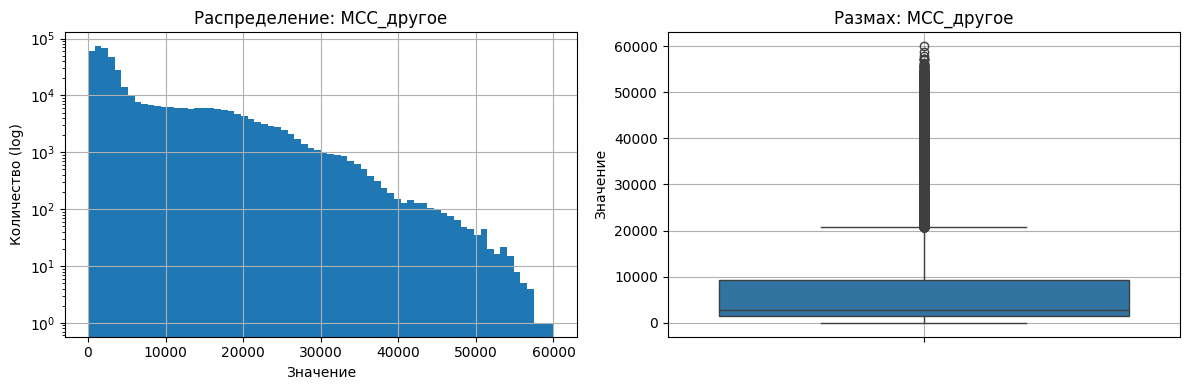

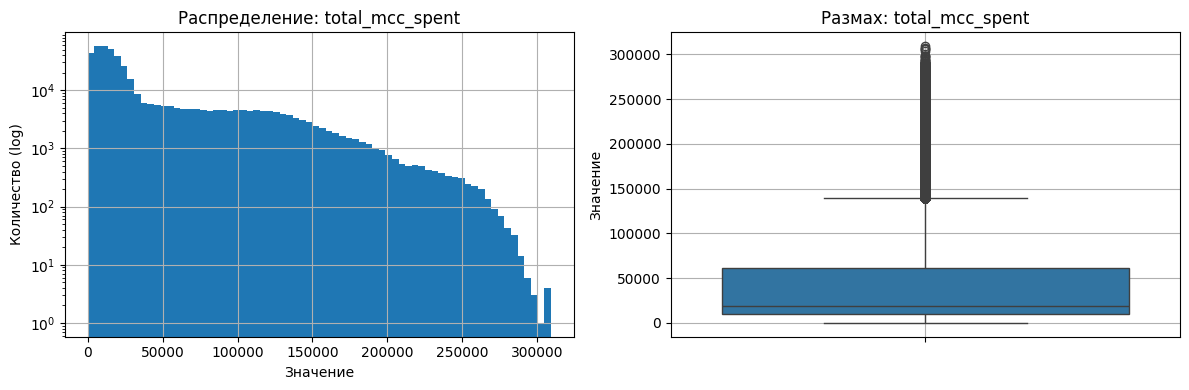

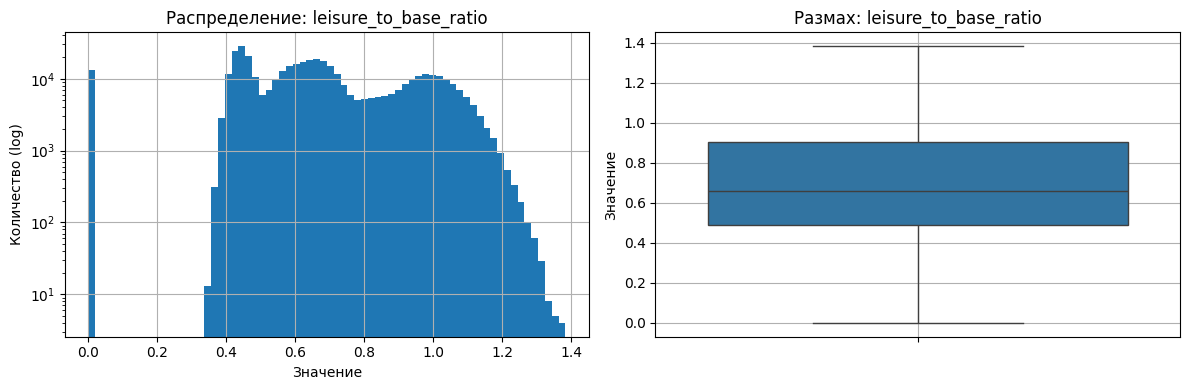

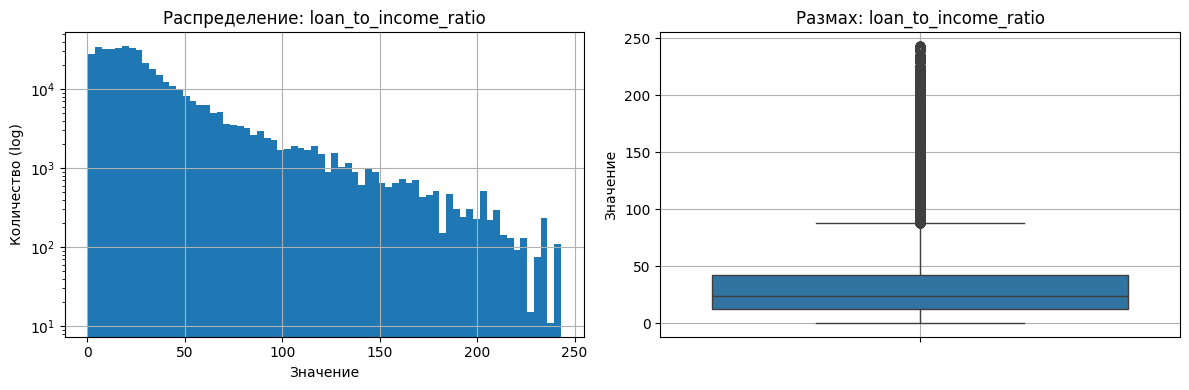

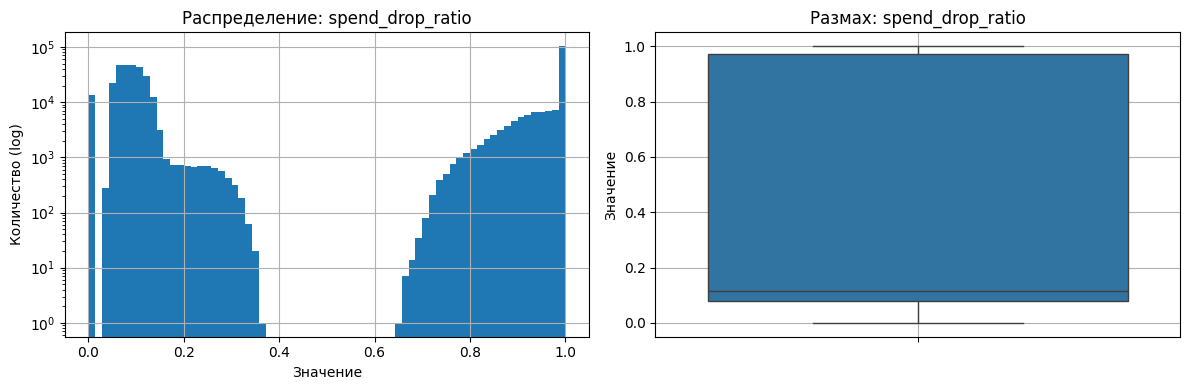

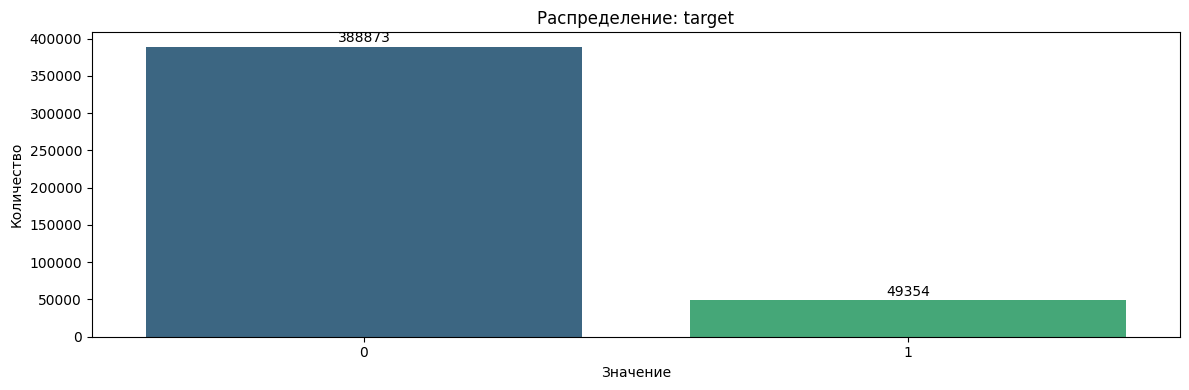

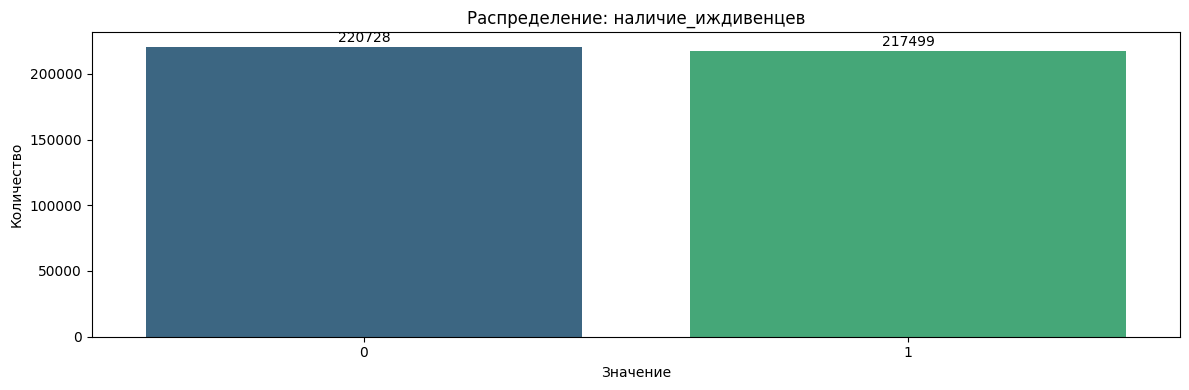

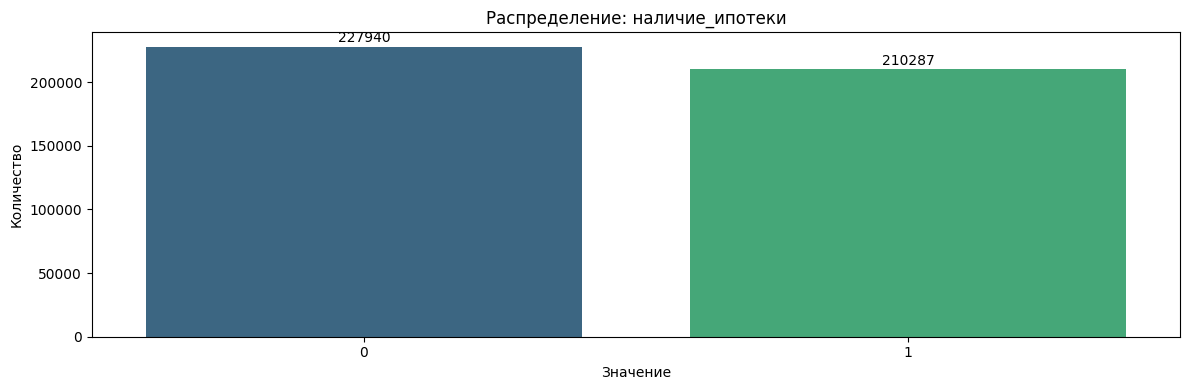

#### категориальные признаки

,семейное_положение
count,438227
unique,3
top,нет семьи
freq,146736


,Признак,Уникальные значения,Кол-во
0,семейное_положение,"[нет семьи, разведённые, есть семья]",3


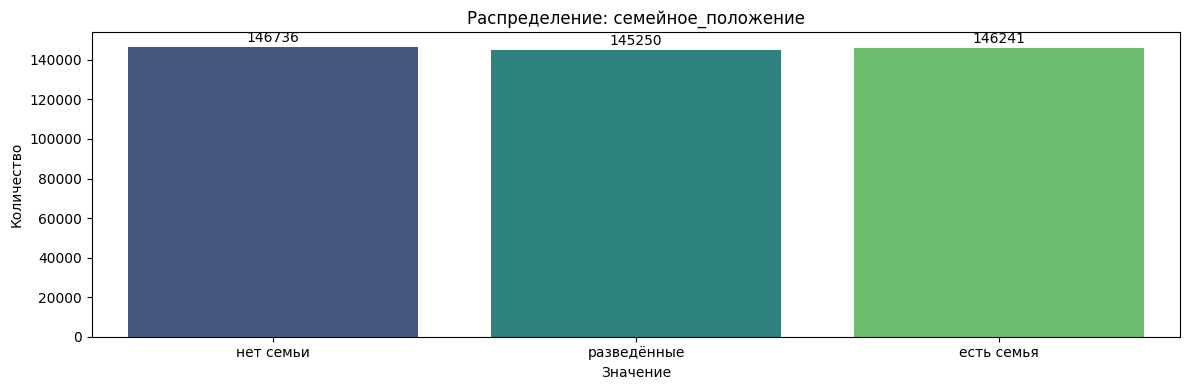

----------------------------------------------------------------------


In [22]:
primary_analysis(eda_df, 'Итоговый dataframe')

Анализ корреляций

In [23]:
def show_heatmap(corr, title, x, y_coef):
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef)
    plt.figure(figsize=(x, dynamic_height))
    
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=.5,
        cbar=False
    )
    
    plt.title(title)
    plt.show()

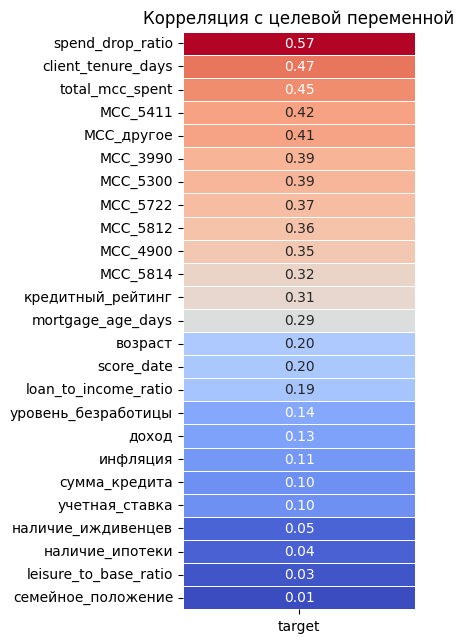

In [24]:
corr_matrix = eda_df.phik_matrix(interval_cols=['target', 'возраст', 'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки', 'client_tenure_days', 'mortgage_age_days', 'учетная_ставка', 'уровень_безработицы', 'инфляция', 'кредитный_рейтинг', 'MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое', 'total_mcc_spent', 'leisure_to_base_ratio', 'loan_to_income_ratio', 'spend_drop_ratio'])
target_corr = corr_matrix[corr_matrix.index != 'target'][['target']].sort_values(by='target', ascending=False)

show_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.3)

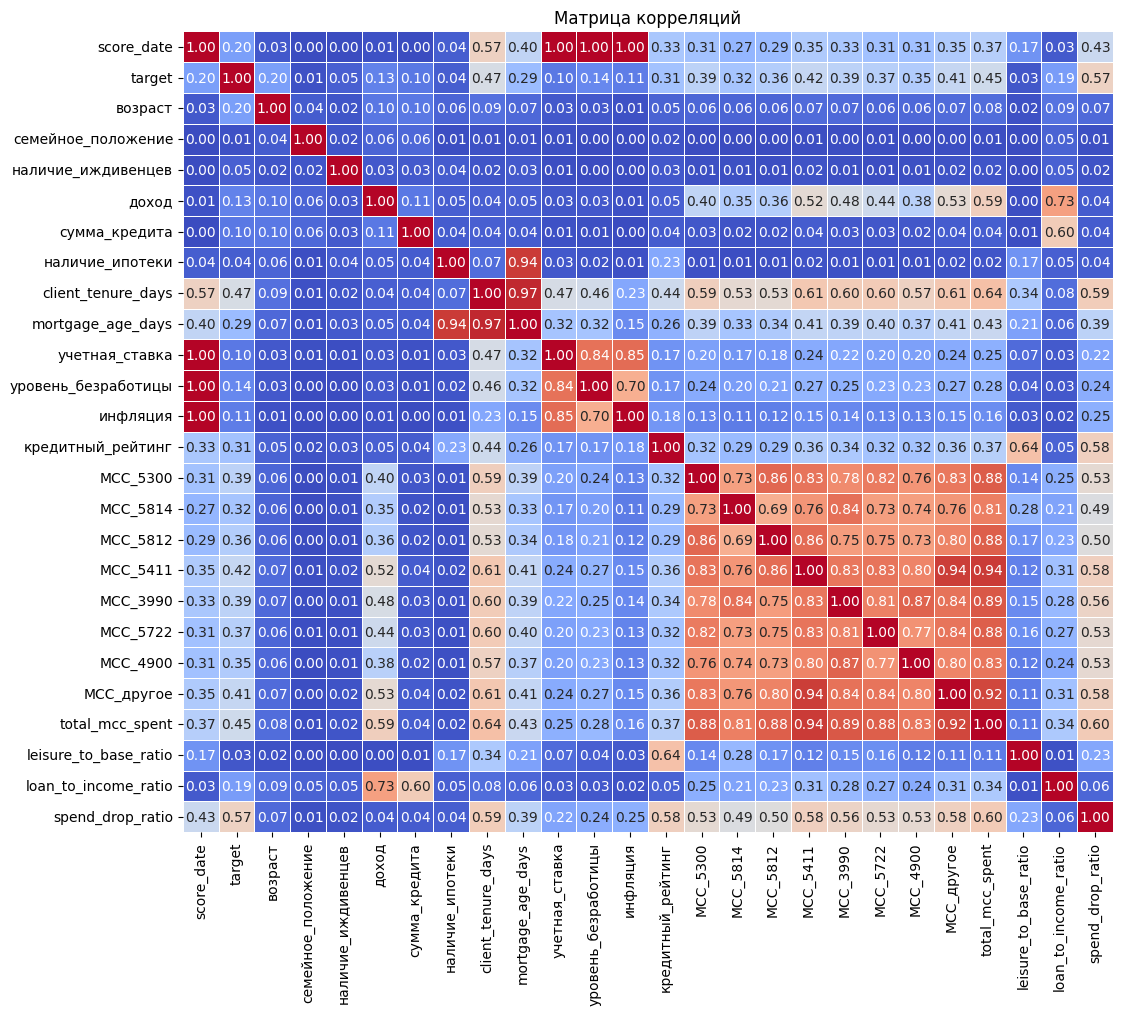

In [25]:
show_heatmap(corr_matrix, title='Матрица корреляций', x=12, y_coef=.4)

Корреляции score_date и макропоказателей не будет при обучении, так как признак score_date нужен только для разделения на фолды, а после будет удален.

client_tenure_days и mortgage_age_days + наличие_ипотеки логически связаны, но несут разный смысл. Высокая корреляция (0.97) здесь объяснима - ипотека физически не может быть старше самого клиента в базе банка. Для моделей с градиентным расчетом ошибки стоит оставить то, что коррелирует меньше, но несет смысл разных признаков: client_tenure_days и наличие_ипотеки.

Показатели MCC_ имеют также высокую корреляцию, означающую, что более обеспеченные клиенты тратят во всех сегментах больше, чем остальные и наоборот. Значит, можно создать общий один признак, обозначающий траты до score_date.

In [26]:
def drop_problematic_columns(df):
    mcc_cols = [col for col in df.columns if 'MCC_' in col]
    cols_to_drop = ['инфляция', 'учетная_ставка', 'mortgage_age_days', *mcc_cols]

    return cols_to_drop

cols_to_drop = drop_problematic_columns(eda_df)
eda_df_no_multi = eda_df.drop(columns=cols_to_drop)

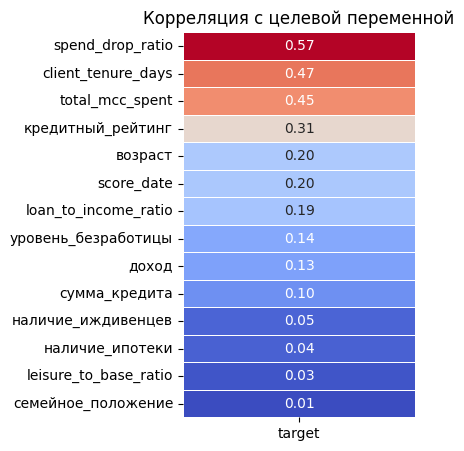

In [27]:
corr_matrix = eda_df_no_multi.phik_matrix(interval_cols=['target', 'возраст', 'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки', 'client_tenure_days', 'mortgage_age_days', 'уровень_безработицы', 'кредитный_рейтинг', 'total_mcc_spent', 'leisure_to_base_ratio', 'loan_to_income_ratio', 'spend_drop_ratio'])
target_corr = corr_matrix[corr_matrix.index != 'target'][['target']].sort_values(by='target', ascending=False)

show_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

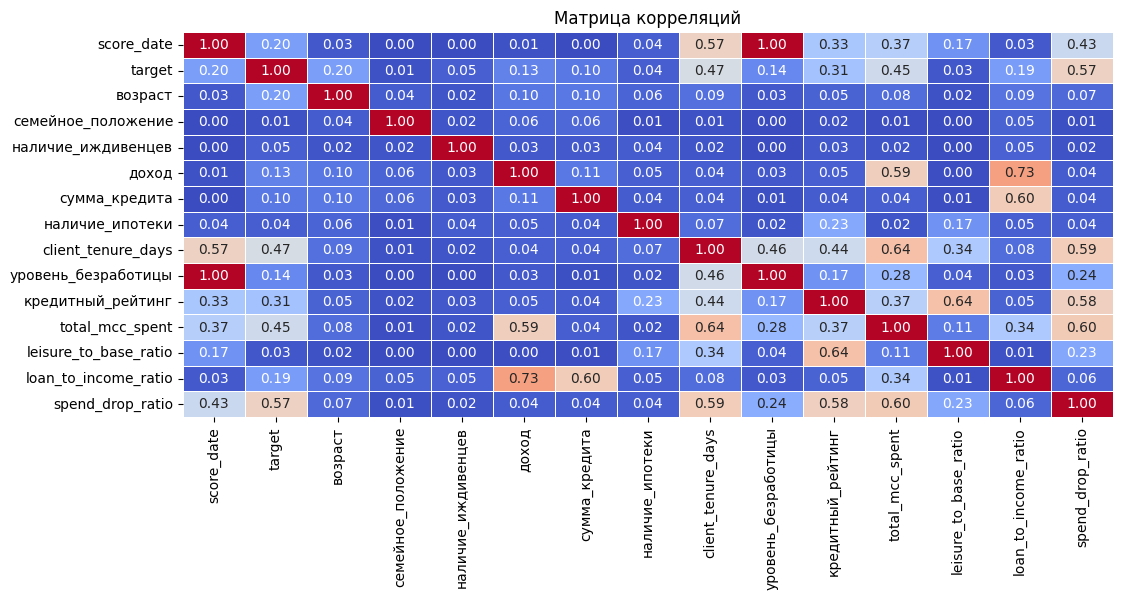

In [28]:
show_heatmap(corr_matrix, title='Матрица корреляций', x=12, y_coef=.3)

TODO: Вывод по EDA

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. При разделении данных на выборки, на которых будет производиться оценка качества и калибровка, используйте размер, равный 1200.

2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели - логистическую регрессию и случайный лес - без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

### КОММЕНТАРИЙ К РАБОТЕ
#### Не до конца понял мысль по 1200 строк для теста и валидации, почему выбрано именно такое число, учитывая кол-во данных в датасете? Буду рад пояснению.

В задаче сказано: "Вам нужно придерживаться описанной выше логики, используя горизонт прогнозирования 12 месяцев.". В материалах курса также об этом писалось: "Длина тестовой выборки должна быть как минимум равна горизонту прогнозирования — сколько шагов вперёд вы хотите предсказывать".

In [29]:
df = df.drop(columns='ID')
df = df.sort_values('score_date').reset_index(drop=True)

max_date = df['score_date'].max()
test_threshold = max_date - pd.DateOffset(years=1)
calib_threshold = test_threshold - pd.DateOffset(years=1)

df_test = df[df['score_date'] >= test_threshold].copy()
df_calib = df[(df['score_date'] >= calib_threshold) & (df['score_date'] < test_threshold)].copy()
df_train = df[df['score_date'] < calib_threshold].copy()

print(f"Обучение: {df_train['score_date'].min().date()} - {df_train['score_date'].max().date()} | Строк: {len(df_train)}")
print(f"Калиброка: {df_calib['score_date'].min().date()} - {df_calib['score_date'].max().date()} | Строк: {len(df_calib)}")
print(f"Тест: {df_test['score_date'].min().date()} - {df_test['score_date'].max().date()} | Строк: {len(df_test)}")

gtss = GroupTimeSeriesSplit(n_splits=3, test_size=12)

groups = df_train['score_date']
X = df_train.drop(columns=['target'])
y = df_train['target']
print(f"Размер всего обучающего датасета: X={X.shape}; y={len(y)}")

Обучение: 2013-02-01 - 2017-11-01 | Строк: 233062
Калиброка: 2017-12-01 - 2018-11-01 | Строк: 93154
Тест: 2018-12-01 - 2019-12-01 | Строк: 112011
Размер всего обучающего датасета: X=(233062, 25); y=233062


In [30]:
useless_cols = ['ID', 'score_date']

num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(include=['object']).columns

problems_cols = drop_problematic_columns(X) + useless_cols
num_cols_without_problems = [col for col in num_cols if col not in problems_cols]
cat_cols_without_problems = [col for col in cat_cols if col not in problems_cols]

In [31]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_without_problems),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols_without_problems),
    ],
    remainder='drop'
).set_output(transform="pandas")

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols),
    ],
    remainder='drop',
).set_output(transform="pandas")

In [32]:
X_transformed_df = linear_preprocessor.fit_transform(X)
X_transformed_df.head()

,num__возраст,num__наличие_иждивенцев,num__доход,num__сумма_кредита,num__наличие_ипотеки,num__client_tenure_days,num__уровень_безработицы,num__кредитный_рейтинг,num__total_mcc_spent,num__leisure_to_base_ratio,num__loan_to_income_ratio,num__spend_drop_ratio,cat__семейное_положение_нет семьи,cat__семейное_положение_разведённые
0,1.474897,-0.988507,0.415168,0.418462,-0.944692,-1.250755,1.154201,-4.311604,-0.984354,-2.653744,-0.302060,-1.251564,1.0,0.0
1,-0.367537,-0.988507,1.469375,-0.896742,-0.944692,-1.250755,1.154201,-4.311604,-0.984354,-2.653744,-0.786250,-1.251564,0.0,1.0
2,0.816885,1.011627,1.437761,0.796410,-0.944692,-1.175508,1.154201,0.013885,0.962299,-1.006975,-0.423997,1.022418,0.0,1.0
3,1.277493,1.011627,-0.815094,1.492627,-0.944692,-1.250755,1.154201,-4.311604,-0.984354,-2.653744,1.066038,-1.251564,1.0,0.0
4,-0.235934,-0.988507,0.217844,1.154578,1.058546,-1.175508,1.154201,0.457892,0.574413,-0.967868,0.001264,1.022418,1.0,0.0


In [33]:
X_transformed_df = tree_preprocessor.fit_transform(X)
X_transformed_df.head()

,cat__семейное_положение_нет семьи,cat__семейное_положение_разведённые,num__возраст,num__наличие_иждивенцев,num__доход,num__сумма_кредита,num__наличие_ипотеки,num__client_tenure_days,num__mortgage_age_days,num__учетная_ставка,num__уровень_безработицы,num__инфляция,num__кредитный_рейтинг,num__MCC_5300,num__MCC_5814,num__MCC_5812,num__MCC_5411,num__MCC_3990,num__MCC_5722,num__MCC_4900,num__MCC_другое,num__total_mcc_spent,num__leisure_to_base_ratio,num__loan_to_income_ratio,num__spend_drop_ratio
0,1.0,0.0,65,0,96507,2391435,0,0,-1.0,5.5,5.7,0.97,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,24.779912,0.0
1,0.0,1.0,37,0,138590,992115,0,0,-1.0,5.5,5.7,0.97,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,7.158633,0.0
2,0.0,1.0,55,1,137328,2793555,0,31,-1.0,5.5,5.7,0.97,603.0,15112.35,5801.92,6434.77,28938.90,2959.570068,10244.07,18173.74,16595.48,104260.800068,0.422846,20.342210,1.0
3,1.0,0.0,62,1,47396,3534300,0,0,-1.0,5.5,5.7,0.97,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,74.569584,0.0
4,1.0,0.0,39,0,88630,3174630,1,31,31.0,5.5,5.7,0.97,665.0,13197.14,4496.55,5001.23,21940.53,2424.159912,8892.09,14706.82,12827.45,83485.969912,0.432887,35.818910,1.0


In [34]:
def get_approval_rate(fn, tn, n):
    return (fn + tn) / n

def get_default_rate(fn, tn):
    return fn / (fn + tn)

def get_missed_defaults_rate(fn, tp):
    return fn / (fn + tp)

In [35]:
results = []

In [36]:
def evaluate_model(pipeline, X, y, groups, name="Model"):
    scores = []
    for train_idx, val_idx in gtss.split(X, y, groups=groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_train, y_train)
        
        y_pred = pipeline.predict(X_val)
        y_proba = pipeline.predict_proba(X_val)[:, 1]

        roc_auc = roc_auc_score(y_val, y_proba)
    
        tn, _, fn, tp = confusion_matrix(y_val, y_pred).ravel()
        approval_rate = get_approval_rate(fn, tn, len(y_val))
        default_rate = get_default_rate(fn, tn)
        missed_defaults_rate = get_missed_defaults_rate(fn, tp)

        metrics = {
            "roc_auc": roc_auc,
            "approval_rate": approval_rate,
            "default_rate": default_rate,
            "missed_defaults_rate": missed_defaults_rate
        }

        display(pd.DataFrame([metrics]))
        scores.append(metrics)

    scores_df = pd.DataFrame(scores)
    
    metrics = {
        'Название модели': name,
        "roc_auc": scores_df["roc_auc"].mean(),
        "approval_rate": scores_df["approval_rate"].mean(),
        "default_rate": scores_df["default_rate"].mean(),
        "missed_defaults_rate": scores_df["missed_defaults_rate"].mean()
    }
    print("Итоговые усредненные метрики:")
    display(pd.DataFrame([metrics]))
    
    results.append(metrics)

In [37]:
def run_optuna(build_pipeline_fn, build_best_pipeline_fn, name, n_trials=5):
    def objective(trial):
        pipeline = build_pipeline_fn(trial)

        scores = []
        for train_idx, val_idx in gtss.split(X, y, groups=groups):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            pipeline.fit(X_train, y_train)
            
            y_pred = pipeline.predict(X_val)

            _, _, fn, tp = confusion_matrix(y_val, y_pred).ravel()
            missed_defaults_rate = get_missed_defaults_rate(fn, tp)
            
            scores.append(missed_defaults_rate)

        mean_score = float(np.mean(scores))

        trial.report(mean_score, step=0)
        if trial.should_prune():
            raise optuna.TrialPruned()

        return mean_score

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, n_jobs=-1)

    # fig1 = optuna.visualization.plot_optimization_history(study)
    # fig2 = optuna.visualization.plot_param_importances(study)

    # display(fig1)
    # display(fig2)

    best_params = study.best_params
    print("Лучшие гиперпараметры:", best_params)
    best_value = study.best_value
    print("Лучшее среднее значение Missed Defaults Rate на кросс-валидации:", round(best_value, 3))

    evaluate_model(build_best_pipeline_fn(best_params), X, y, groups, name=name)

    return best_params

In [38]:
def get_base_pipeline(preprocessor, model):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
def get_ros_pipeline(preprocessor, model):
    return ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('over', RandomOverSampler(random_state=RANDOM_STATE)),
        ('model', model)
    ])
    
def get_smote_pipeline(preprocessor, model):
    return ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', model)
    ])
    
def get_rus_pipeline(preprocessor, model):
    return ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', RandomUnderSampler(random_state=RANDOM_STATE)),
        ('model', model)
    ])
    
def get_cc_pipeline(preprocessor, model):
    return ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('cluster', ClusterCentroids(random_state=RANDOM_STATE)),
        ('model', model)
    ])

In [ ]:
def get_linear_params(trial):
    params = {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "fit_intercept": True,
        "tol": trial.suggest_float("tol", 1e-4, 1e-2, log=True),
        "max_iter": trial.suggest_int("max_iter", 2000, 20000),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "newton-cg", "newton-cholesky", "saga"]),
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "random_state": RANDOM_STATE,
    }

    solver = params["solver"]
    if solver in ["lbfgs", "newton-cg", "newton-cholesky"]:
        params["l1_ratio"] = 0
    elif solver == "saga":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
    
    return params

def build_pipeline_fn(trial):
    model = LogisticRegression(**get_linear_params(trial))
    return get_base_pipeline(linear_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = LogisticRegression(**best_params, random_state=RANDOM_STATE)
    return get_base_pipeline(linear_preprocessor, model)

lr_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression")

def build_pipeline_fn(trial):
    model = LogisticRegression(**get_linear_params(trial))
    return get_ros_pipeline(linear_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = LogisticRegression(**best_params, random_state=RANDOM_STATE)
    return get_ros_pipeline(linear_preprocessor, model)

lr_os_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression with Over Sampler")

def build_pipeline_fn(trial):
    model = LogisticRegression(**get_linear_params(trial))
    return get_smote_pipeline(linear_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = LogisticRegression(**best_params, random_state=RANDOM_STATE)
    return get_smote_pipeline(linear_preprocessor, model)

lr_smote_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression with SMOTE")

def build_pipeline_fn(trial):
    model = LogisticRegression(**get_linear_params(trial))
    return get_rus_pipeline(linear_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = LogisticRegression(**best_params, random_state=RANDOM_STATE)
    return get_rus_pipeline(linear_preprocessor, model)

lr_us_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression with Under Sampler")

def build_pipeline_fn(trial):
    model = LogisticRegression(**get_linear_params(trial))
    return get_cc_pipeline(linear_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = LogisticRegression(**best_params, random_state=RANDOM_STATE)
    return get_cc_pipeline(linear_preprocessor, model)

lr_cc_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression with Cluster Centroids")

[I 2026-02-23 21:38:34,911] A new study created in memory with name: no-name-02226266-56cc-4ed4-bd85-0196ee7943f0


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-23 21:38:43,147] Trial 1 finished with value: 0.9918310719626536 and parameters: {'class_weight': None, 'tol': 0.0017057458665415968, 'max_iter': 8358, 'solver': 'newton-cg', 'C': 0.00010728888467653465}. Best is trial 1 with value: 0.9918310719626536.
[I 2026-02-23 21:38:50,359] Trial 2 finished with value: 0.858268371676222 and parameters: {'class_weight': None, 'tol': 0.00024862204470100277, 'max_iter': 10209, 'solver': 'lbfgs', 'C': 0.08379868014355026}. Best is trial 2 with value: 0.858268371676222.
[I 2026-02-23 21:38:54,074] Trial 0 finished with value: 0.1522058806451313 and parameters: {'class_weight': 'balanced', 'tol': 0.002893731458981132, 'max_iter': 19140, 'solver': 'saga', 'C': 0.005026485747907803, 'l1_ratio': 0.3238412586448529}. Best is trial 0 with value: 0.1522058806451313.
[I 2026-02-23 21:38:56,083] Trial 3 finished with value: 0.15688728675701005 and parameters: {'class_weight': 'balanced', 'tol': 0.00016599749966775046, 'max_iter': 17683, 'solver': 'n

,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.892883,0.7291,0.022335,0.159447


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.894376,0.731006,0.021636,0.156427


...

Итоговые усредненные метрики:


,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,Logistic Regression with Over Sampler,0.891661,0.707525,0.016642,0.116278


[I 2026-02-23 21:40:06,677] A new study created in memory with name: no-name-1a1d3362-aaee-415e-b234-5db56fafc370


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-02-23 21:41:23,548] Trial 1 finished with value: 0.16159980975217858 and parameters: {'class_weight': 'balanced', 'tol': 0.006467143054926993, 'max_iter': 18694, 'solver': 'newton-cholesky', 'C': 0.026235073467856515}. Best is trial 1 with value: 0.16159980975217858.
[I 2026-02-23 21:41:27,515] Trial 0 finished with value: 0.16551075200143453 and parameters: {'class_weight': 'balanced', 'tol': 0.0002790781069184152, 'max_iter': 11939, 'solver': 'newton-cg', 'C': 41.39556857108239}. Best is trial 1 with value: 0.16159980975217858.


In [ ]:
def get_decision_tree_params(trial):
    return {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "criterion": trial.suggest_categorical("criterion", ["entropy", "log_loss"]),
        "splitter": "best",
        "max_depth": trial.suggest_int("max_depth", 4, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 60),
        "min_samples_split": trial.suggest_int("min_samples_split", 20, 150),
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 1e-5, 2e-3, log=True),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 5e-3, log=True),
        "random_state": RANDOM_STATE,
    }

def build_pipeline_fn(trial):
    model = DecisionTreeClassifier(**get_linear_params(trial))
    return get_base_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
    return get_base_pipeline(tree_preprocessor, model)

dt_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Decision Tree Classifier")

def build_pipeline_fn(trial):
    model = DecisionTreeClassifier(**get_linear_params(trial))
    return get_ros_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
    return get_ros_pipeline(tree_preprocessor, model)

dt_os_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Decision Tree Classifier with Over Sampler")

def build_pipeline_fn(trial):
    model = DecisionTreeClassifier(**get_linear_params(trial))
    return get_smote_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
    return get_smote_pipeline(tree_preprocessor, model)

dt_smote_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Decision Tree Classifier with SMOTE")

def build_pipeline_fn(trial):
    model = DecisionTreeClassifier(**get_linear_params(trial))
    return get_rus_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
    return get_rus_pipeline(tree_preprocessor, model)

dt_us_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Decision Tree Classifier with Under Sampler")

def build_pipeline_fn(trial):
    model = DecisionTreeClassifier(**get_linear_params(trial))
    return get_cc_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
    return get_cc_pipeline(tree_preprocessor, model)

dt_cc_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Decision Tree Classifier with Cluster Centroids")

In [ ]:
def get_decision_tree_params(trial):
    return {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "n_estimators": trial.suggest_int("n_estimators", 30, 100),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 50, 200),
        "min_samples_split": trial.suggest_int("min_samples_split", 50, 300),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3]),
        "bootstrap": True,
        "max_samples": trial.suggest_float("max_samples", 0.3, 0.5),
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 1e-6, 1e-2, log=True),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-6, 1e-2, log=True),
        "criterion": "gini",
        "random_state": RANDOM_STATE,
    }

def build_pipeline_fn(trial):
    model = RandomForestClassifier(**get_linear_params(trial))
    return get_base_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
    return get_base_pipeline(tree_preprocessor, model)

rf_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest Classifier")

def build_pipeline_fn(trial):
    model = RandomForestClassifier(**get_linear_params(trial))
    return get_ros_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
    return get_ros_pipeline(tree_preprocessor, model)

rf_os_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest Classifier with Over Sampler")

def build_pipeline_fn(trial):
    model = RandomForestClassifier(**get_linear_params(trial))
    return get_smote_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
    return get_smote_pipeline(tree_preprocessor, model)

rf_smote_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest Classifier with SMOTE")

def build_pipeline_fn(trial):
    model = RandomForestClassifier(**get_linear_params(trial))
    return get_rus_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
    return get_rus_pipeline(tree_preprocessor, model)

rf_us_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest Classifier with Under Sampler")

def build_pipeline_fn(trial):
    model = RandomForestClassifier(**get_linear_params(trial))
    return get_cc_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
    return get_cc_pipeline(tree_preprocessor, model)

rf_cc_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest Classifier with Cluster Centroids")

In [ ]:
pd.DataFrame(results) \
    .sort_values(by='missed_defaults_rate') \
    .style.background_gradient(cmap='coolwarm')

In [ ]:
# def calculate_ece(y_true, y_prob, n_bins=10):
#     bins = np.linspace(0, 1, n_bins + 1)
#     ece = 0
#     n = len(y_true)
#     for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
#         if i == n_bins - 1:
#             mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
#         else:
#             mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
#         if np.sum(mask) > 0:
#             bin_conf = np.mean(y_prob[mask])
#             bin_acc = np.mean(y_true[mask])
#             ece += np.abs(bin_conf - bin_acc) * np.sum(mask)
#     return ece / n

# def calculate_mce(y_true, y_prob, n_bins=10):
#     bins = np.linspace(0, 1, n_bins + 1)
#     max_error = 0
#     for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
#         if i == n_bins - 1:
#             mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
#         else:
#             mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
#         if np.sum(mask) > 0:
#             bin_conf = np.mean(y_prob[mask])
#             bin_acc = np.mean(y_true[mask])
#             max_error = max(max_error, np.abs(bin_conf - bin_acc)) 
#     return max_error

In [ ]:
# def sigmoid_numpy(x):
#     return 1 / (1 + np.exp(-x))

# def show_calibration_curve(y_true, y_proba):
#     prob_true_svm, prob_pred_svm = calibration_curve(y_true, y_proba)

#     CalibrationDisplay(prob_true_svm, prob_pred_svm, y_true).plot(label='SVM', color='green')
#     plt.title("Диаграмма калибровки")
#     plt.xlabel("Средняя предсказанная вероятность")
#     plt.ylabel("Фактическая доля положительных исходов")
#     plt.legend()
#     plt.grid(True)
#     plt.show()

# def check_calibration(y_true, y_proba):
#     sigmoid_y_proba = sigmoid_numpy(y_proba)
    
#     show_calibration_curve(y_true, sigmoid_y_proba)

#     brier_score = brier_score_loss(y_true, sigmoid_y_proba)
#     print(f"\nОценка Бриера: {brier_score:.4f}")

#     ece_score = calculate_ece(y_true, sigmoid_y_proba)
#     print(f"\nОценка ECE: {ece_score:.4f}")

#     mce_score = calculate_mce(y_true, sigmoid_y_proba)
#     print(f"\nОценка MCE: {mce_score:.4f}")

#     return brier_score, ece_score, mce_score

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate - не менее 65%;
    * default rate - не более 2%;
    * missed defaults rate - не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.

